In [1]:
import sys
import time
import pathlib
cur_path = pathlib.Path().resolve().parent.absolute()
src_loc = cur_path.joinpath("src")
util_loc = src_loc.joinpath("utils")
sys.path.append(str(cur_path))
sys.path.append(str(src_loc))
sys.path.append(str(util_loc))

# 1 Load Data

### 1.1 Setup env and load packages

In [2]:
# load the libraries and initial settings
import os
import pathlib
import time
import datetime
import subprocess
import pyarrow as pa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from src.conf import Conf
from src.utils.utils import elapsed_time, save_data, load_data
from src.utils.sql import sql
# Load configuration
confparam_path = cur_path.joinpath("src", "conf", "conf_dev.yml")
dataparam_path = cur_path.joinpath("src", "data", "ctp_dbt_model", "dbt_project.yml")
conf = Conf(confparam_path, dataparam_path )
project_start_time = time.time()

### 1.2 query data from EDH

#### 1.2.1 Query node features

In [ ]:
# query for customer relationship

# cust_query="""
# SELECT *
# FROM dl_analytics.ctp_customer_connection_dbt
# """

cust_query="""
SELECT *
FROM dl_analytics.ctp_participant_cust_connection_dbt
"""

# query for doctor&lawyer relationship

doc_lawyer_query="""
SELECT *
FROM dl_analytics.ctp_doctor_lawyer_pair_dbt
"""

# query for docotr&psych relationship

doc_psych_query="""
SELECT *
FROM dl_analytics.ctp_doctor_psych_pair_dbt
"""

# query for doctor&repairer relationship

doc_repair_query="""
SELECT *
FROM dl_analytics.ctp_doctor_repairer_pair_dbt
"""

# query for payment relationship

payment_query="""
SELECT *
FROM dl_analytics.ctp_payment_connection_dbt
"""

# query for vehicle relationship

vehicle_query="""
SELECT *
FROM dl_analytics.ctp_vehicle_connection_dbt
"""

In [4]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
cust_df = sql( conf=conf, fn="get", sql=cust_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.072
Total elapsed time: 0:0:01.106


In [5]:
# Check for duplicates based on all columns
print('*'*60)
print("check duplicates")
duplicates = cust_df[cust_df.duplicated()]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(cust_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 5014
Number of duplicates is 0


In [6]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_lawyer_df = sql( conf=conf, fn="get", sql=doc_lawyer_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.944
Total elapsed time: 0:0:02.100


In [7]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_psych_df = sql(conf=conf, fn="get", sql=doc_psych_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.939
Total elapsed time: 0:0:03.064


In [8]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_repair_df = sql(conf=conf, fn="get", sql=doc_repair_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.132
Total elapsed time: 0:0:04.233


In [9]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
payment_df = sql(conf=conf, fn="get", sql=payment_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:2:06.048
Total elapsed time: 0:2:10.308


In [10]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
vehicle_df = sql(conf=conf, fn="get", sql=vehicle_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:02.523
Total elapsed time: 0:2:12.854


In [11]:
vehicle_df

,claim_number_1,claim_number_2
0,NWRND2300159,NWRND2200178
1,NWRND2200005,NWRND2400158
2,NWRND2300159,NWRND2400032
3,NWRND2200005,NWRND2400180
4,NWRND2200005,NWRND2100152
...,...,...
272447,NWRND2400083,NWRND2100230
272448,NWRND2400028,NWRND2400173
272449,NWRND2300098,NWRND2100028
272450,NWRND2300098,NWRND2300182


#### 1.2.2 Query node features

In [12]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
node_query='SELECT * FROM dl_analytics.ctp_node_features_dbt'
node_df = sql(conf=conf, fn="get", sql=node_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:02.616
Total elapsed time: 0:2:15.531


In [13]:
node_df

,late_lodgement_days,late_report_days,cause_of_loss_name,max_late_treatment_days,max_amt_fitness_certificate_per_exp,cust_max_investigation_count,cust_max_denial_count,cust_max_ctp_claim_count_total,cust_min_last_cancel_arrear_days,max_days_of_minor_assess_to_lodgement,...,ambulance_attendance_flag,accident_injury_mismatch_flag,psych_claim_flag,claim_number,policy_number,claim_lodgement_date,claim_loss_date,investigation_flag,triage_flag,alleged_flag
0,1,1,62 Accident,NaT,0.000,NaN,NaN,NaN,NaN,0.000,...,0.000,NaN,0,NWRTP2402639,CTP774789925,2024-09-27,2024-09-26,0,0,0
1,11,11,62 Accident,NaT,0.000,0.000,0.000,0.000,0.000,1.000,...,1.000,NaN,0,NWRTP2400937,CTP554704276,2024-04-15,2024-04-04,0,0,0
2,10,10,62 Accident,696 days,16.000,NaN,NaN,NaN,NaN,0.000,...,1.000,NaN,1,NWRND2200280,NDS*11111111,2022-12-30,2022-12-20,0,0,0
3,20,20,67 Struck animal,NaT,0.000,0.000,0.000,0.000,0.000,56.000,...,0.000,NaN,1,NWRTP2100733,CTP689717515,2021-03-26,2021-03-06,0,0,0
4,1,1,62 Accident,215 days,7.000,0.000,0.000,0.000,0.000,12.000,...,0.000,NaN,0,NWRTP2400505,CTP759928832,2024-02-28,2024-02-27,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12915,12,12,30 Rear end,543 days,26.000,0.000,0.000,0.000,0.000,325.000,...,0.000,NaN,1,NWRTP2101065,CTP448445157,2021-05-03,2021-04-21,0,0,0
12916,24,24,99 Unknown,NaT,NaN,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0,NWRTP2102805,CTP717826988,2021-12-28,2021-12-04,0,0,0
12917,89,89,29 Other opposing,NaT,0.000,0.000,0.000,0.000,209.000,0.000,...,0.000,0.000,1,NWRTP2100450,CTP655840283,2021-02-24,2020-11-27,0,0,0
12918,19,19,62 Accident,0 days,1.000,0.000,0.000,0.000,386.000,0.000,...,1.000,0.000,0,NWRTP2200994,CTP719278556,2022-05-27,2022-05-08,0,0,0


In [14]:
# Check for duplicates based on claim number
print('*'*60)
print("check duplicates")
duplicates = node_df[node_df.duplicated(subset=['claim_number'])]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(node_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 12920
Number of duplicates is 509


### 1.3 create pa schema and save parquet

In [4]:
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(cust_df)
# save data 
save_data(cust_df, conf.data_path, 'customer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_lawyer_df)
# save data 
save_data(doc_lawyer_df, conf.data_path, 'doc_lawyer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_psych_df)
# save data 
save_data(doc_psych_df, conf.data_path, 'doc_psych_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_repair_df)
# save data 
save_data(doc_repair_df, conf.data_path, 'doc_repair_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(payment_df)
# save data 
save_data(payment_df, conf.data_path, 'payment_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(vehicle_df)
# save data 
save_data(vehicle_df, conf.data_path, 'vehicle_connection_data', data_extension='parquet', schema=new_schema)


NameError: name 'cust_df' is not defined

In [16]:
# save claim node data
new_schema = pa.Schema.from_pandas(node_df)
save_data(node_df, conf.data_path, 'node_feature', data_extension='parquet', schema=new_schema)

Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet


# 2 Data preprocessing

### 2.1 load data locally

In [3]:
import decimal
from scipy import sparse
from category_encoders import BinaryEncoder
import torch
from torch_geometric.data import Data
import numpy as np 
import pandas as pd
from torch_geometric.utils import to_networkx, degree
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected

In [4]:
project_start_time = time.time()

print('*' * 60)
print("load data locally ...")

function_start_time = time.time()
cust_df=load_data(conf.data_path, 'customer_connection_data',  data_extension='parquet')
doc_lawyer_df=load_data(conf.data_path, 'doc_lawyer_connection_data',  data_extension='parquet')
doc_psych_df=load_data(conf.data_path, 'doc_psych_connection_data',  data_extension='parquet')
doc_repair_df=load_data(conf.data_path, 'doc_repair_connection_data',  data_extension='parquet')
payment_df=load_data(conf.data_path, 'payment_connection_data',  data_extension='parquet')
vehicle_df=load_data(conf.data_path, 'vehicle_connection_data',  data_extension='parquet')
node_df=load_data(conf.data_path, 'node_feature',  data_extension='parquet')

elapsed_time('load data', project_start_time, function_start_time)

************************************************************
load data locally ...
Loading data locally: C:\GitHub\CTP_syndicate_model\data\customer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\payment_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet

Elapsed time (load data): 0:0:04.474
Total elapsed time: 0:0:04.475


In [5]:
df_geo=pd.read_csv('geocoded_address.csv')
df_geo.head(10)

,claim_number,claim_exposure_id,claimant_name,claimant_address,supplier_name,supplier_role_name,supplier_address,claimant_longitude,claimant_latitude,ext_GEO_ID,gnafPID,supplier_longitude,supplier_latitude
0,NWRND1800164,1,Joshua Cox,"37 Menangle STREET, GANMAIN, NSW, 2702, Australia",gerard malouf and partners solicitors,Legal,"PO BOX 463 , PARRAMATTA, NSW, 2124, AU",147.037,-34.797,AGANSW704808475,GANSW704808475,151.007,-33.814
1,NWRND1900051,2,NASSOUH EL DEBAL,"31 SACKVILLE ST, FAIRFIELD, NSW, 2165, Australia",fit by physio pty ltd,Service Provider,"Shop 2, 363 Beamish Street , CAMPSIE, NSW, 219...",150.949,-33.866,AGANSW716741848,GANSW716741848,151.104,-33.915
2,NWRND1900055,1,Mildred Villapando,"75 Kleins Rd, NORTHMEAD, NSW, 2152, Australia",exphys rehab pty ltd,Service Provider,"PO Box 2154 , Woolooware, NSW, 2230, AU",150.993,-33.790,AGANSW705571192,GANSW705571192,151.141,-34.043
3,NWRND1900118,1,Nicole Shorrock,"2 Inkerman Rd, EMU HEIGHTS, NSW, 2750, Australia",rosalind dayman,Service Provider,"Genesis, Ste 35 76 Rawson St , EPPING, NSW, 21...",150.647,-33.734,AGANSW704686594,GANSW704686594,151.081,-33.772
4,NWRND1900171,1,Darren Hunt,"21 Hereford St, HOBARTVILLE, NSW, 2753, Australia",penrith physiotherapy sports centre,Service Provider,Nepean Private Specialist Centre 1A Barber Ave...,150.745,-33.601,AGANSW704965734,GANSW704965734,150.714,-33.758
5,NWRND2000004,1,SUSAN HOWE,"1-5 PEEL ST, TOUKLEY, NSW, 2263, Australia",interpsych,Service Provider,"Po Box 3125 , ASQUITH, NSW, 2077, AU",151.539,-33.263,AGANSW717749058,GANSW717749058,151.116,-33.687
6,NWRND2000033,1,Jake Bevan,"40 Promenade Av, BATEAU BAY, NSW, 2261, Australia",dws cleaning services pty ltd,Service Provider,"3 Lake Street , LONG JETTY, NSW, 2261, AU",151.466,-33.381,AGANSW704027218,GANSW704027218,151.479,-33.363
7,NWRND2000079,1,Alan Abdo,"110 Sir John Jamison Cct, GLENMORE PARK, NSW, ...",independent living specialists,Service Provider,"PO Box 889 , LANE COVE, NSW, 2066, AU",150.658,-33.788,AGANSW704814019,GANSW704814019,151.167,-33.818
8,NWRND2100001,1,Challie Takis,"34 Elliott Rd, BANYO, QLD, 4014, Australia",dr andrew ryan,Service Provider,"Holy Spirit Northside Hospital 627 Rode Road ,...",153.069,-27.373,AGAQLD154997610,GAQLD154997610,153.023,-27.389
9,NWRND2100001,1,Challie Takis,"34 Elliott Rd, BANYO, QLD, 4014, Australia",dr colin crowe,Service Provider,"Narcosia Anaesthesia Group PO Box 239 , SPRING...",153.069,-27.373,AGAQLD154997610,GAQLD154997610,153.024,-27.459


### Calculate distance

In [6]:
# Earth's radius in kilometers (you can change this to miles if needed)
R = 6371.0

# Convert the longitude and latitude from degrees to radians.
# Ensure the columns are numeric (using .astype(float) if needed).
claimant_lon_rad = np.radians(df_geo['claimant_longitude'].astype(float))
claimant_lat_rad = np.radians(df_geo['claimant_latitude'].astype(float))
supplier_lon_rad = np.radians(df_geo['supplier_longitude'].astype(float))
supplier_lat_rad = np.radians(df_geo['supplier_latitude'].astype(float))

# Calculate the differences between supplier and claimant coordinates.
dlat = supplier_lat_rad - claimant_lat_rad
dlon = supplier_lon_rad - claimant_lon_rad

# Compute the Haversine formula.
a = np.sin(dlat / 2) ** 2 + np.cos(claimant_lat_rad) * np.cos(supplier_lat_rad) * np.sin(dlon / 2) ** 2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Calculate the distance.
df_geo["max_claimant_supplier_distance"] = R * c

In [7]:
df_distance = df_geo.groupby('claim_number', as_index=False)["max_claimant_supplier_distance"].max()
df_distance

,claim_number,max_claimant_supplier_distance
0,NWRND1800030,740.966
1,NWRND1800058,732.542
2,NWRND1800109,253.793
3,NWRND1800121,107.711
4,NWRND1800140,226.336
...,...,...
5909,NWRTP2500147,0.884
5910,NWRTP2500161,19.333
5911,NWRTP2500165,1.548
5912,NWRTP2500178,720.865


In [8]:
merged_df = pd.merge(node_df, df_distance, on='claim_number', how='left')
merged_df

,late_lodgement_days,late_report_days,cause_of_loss_name,max_late_treatment_days,max_amt_fitness_certificate_per_exp,cust_max_investigation_count,cust_max_denial_count,cust_max_ctp_claim_count_total,cust_min_last_cancel_arrear_days,max_days_of_minor_assess_to_lodgement,...,accident_injury_mismatch_flag,psych_claim_flag,claim_number,policy_number,claim_lodgement_date,claim_loss_date,investigation_flag,triage_flag,alleged_flag,max_claimant_supplier_distance
0,15,15,62 Accident,NaT,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,1,NWRTP2102781,CTP700616464,2021-12-24,2021-12-09,0,0,0,162.886
1,13,13,30 Rear end,17 days,3.000,0.000,0.000,0.000,396.000,444.000,...,0.000,0,NWRTP2201643,CTP704232644,2022-08-16,2022-08-03,0,0,0,NaN
2,19,19,67 Struck animal,344 days,14.000,0.000,0.000,0.000,0.000,0.000,...,NaN,0,NWRTP2303192,CTP734161018,2023-12-29,2023-12-10,0,0,0,1483.905
3,42,42,29 Other opposing,92 days,2.000,NaN,NaN,NaN,NaN,0.000,...,NaN,0,NWRTP2401989,CTP778142728,2024-07-31,2024-06-19,0,1,0,15.644
4,6,6,71 Off road left -> object,1031 days,1.000,0.000,0.000,0.000,0.000,1129.000,...,NaN,1,NWRTP2102179,CTP709608966,2021-09-27,2021-09-21,0,0,0,947.662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12915,13,13,29 Other opposing,85 days,8.000,NaN,NaN,NaN,NaN,0.000,...,NaN,0,NWRTP2402227,CTP784635770,2024-08-20,2024-08-07,0,0,0,3289.754
12916,40,40,62 Accident,350 days,13.000,0.000,0.000,0.000,0.000,140.000,...,0.000,0,NWRTP2302660,CTP694819812,2023-11-01,2023-09-22,0,0,0,NaN
12917,21,21,62 Accident,5 days,1.000,0.000,0.000,0.000,136.000,0.000,...,NaN,0,NWRTP2401292,CTP628125476,2024-05-20,2024-04-29,0,1,0,16.122
12918,11,11,62 Accident,66 days,4.000,1.000,1.000,0.000,278.000,50.000,...,NaN,0,NWRTP2400405,CTP608250929,2024-02-20,2024-02-09,0,1,0,473.563


### 2.2 Node features engineering 

In [9]:
input_dataframe=merged_df.copy()

In [10]:
def data_transformation(input_dataframe):
        """
        Function to perform data preparation steps on the given model_data DataFrame.

        Args:
        - input_dataframe: DataFrame containing the data to be prepared

        Returns:
        - model_data: DataFrame with the prepared data including node features
        """

        # Remove duplicates from input dataframe
        input_dataframe = input_dataframe.drop_duplicates(subset=['claim_number'], keep='first')

        # Convert datatype to get over Decimal
        for x in list(input_dataframe.columns):
                if (input_dataframe[x].dtype == 'object') & (type(input_dataframe[x][0]) == decimal.Decimal):
                        input_dataframe[x] = input_dataframe[x].astype('float')
        # transfor timedelta to days              
        input_dataframe.loc[:,'max_late_treatment_days']=input_dataframe['max_late_treatment_days'].dt.days

        # fill the missing value
        fill_zero_cols = [
        "late_lodgement_days",
        "late_report_days",
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "cust_max_investigation_count",
        "cust_max_denial_count",
        "cust_max_ctp_claim_count_total",
        "cust_min_last_cancel_arrear_days",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_attend_hospital_immediately_amt",
        "not_injured_is_only_insured_driver",
        "max_days_late_recovery_from_loss",
        "self_employed_flag",
        "max_pre_accident_weekly_earning",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "police_involved_flag",
        "late_report_police_days",
        "ambulance_attendance_flag",
        "accident_injury_mismatch_flag",
        "psych_claim_flag",
        "max_claimant_supplier_distance"
        ]
        for x in fill_zero_cols:
                input_dataframe[x].fillna(0, inplace=True)


        fill_max_cols=["cause_of_loss_name"]
        for x in fill_max_cols:
                # Replace empty strings with NaN
                input_dataframe[x].replace('', pd.NA, inplace=True)
                # Fill NaN with 'missing'
                input_dataframe[x].fillna('62 Accident', inplace=True)

        # Grouping categories of cause of loss name with count less than 50 as 'Others'
        input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(
        lambda x: x if input_dataframe['cause_of_loss_name'].value_counts()[x] >= 100 else 'Others')


        # Column Selection
        # binary_features
        binary_cols = ["cause_of_loss_name"]
        # Numeric columns
        num_cols = [
        "late_lodgement_days",
        "late_report_days",
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "cust_max_investigation_count",
        "cust_max_denial_count",
        "cust_max_ctp_claim_count_total",
        "cust_min_last_cancel_arrear_days",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_attend_hospital_immediately_amt",
        "not_injured_is_only_insured_driver",
        "max_days_late_recovery_from_loss",
        "max_pre_accident_weekly_earning",
        "late_report_police_days",
        "max_claimant_supplier_distance"
        ]
        #One hot encodin
        ohe_cols = [
        "self_employed_flag",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "police_involved_flag",
        "ambulance_attendance_flag",
        "accident_injury_mismatch_flag",
        "psych_claim_flag"
        ""
        ]
        #id_columns
        id_cols = ['claim_number']

        features=  num_cols + ohe_cols+ binary_cols

        # Initialize the BinaryEncoder for binary cols
        encoder = BinaryEncoder(cols=['cause_of_loss_name'])

        # Fit and transform the 'cause_of_loss_name' column in the DataFrame
        df_encoded = encoder.fit_transform(input_dataframe)

        df_encoded[ohe_cols]=df_encoded[ohe_cols].astype(int)
        return df_encoded

In [11]:
# perform data processing and engineering
df_encoded=data_transformation(input_dataframe)
df_encoded.info()

C:\Users\s745998\AppData\Local\Temp\ipykernel_14072\2909763355.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe[x].fillna(0, inplace=True)
C:\Users\s745998\AppData\Local\Temp\ipykernel_14072\2909763355.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe[x].replace('', pd.NA, inplace=True)
C:\Users\s745998\AppData\Local\Temp\ipykernel_14072\2909763355.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

<class 'pandas.core.frame.DataFrame'>
Index: 12411 entries, 0 to 12919
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   late_lodgement_days                    12411 non-null  int64  
 1   late_report_days                       12411 non-null  int64  
 2   cause_of_loss_name_0                   12411 non-null  int64  
 3   cause_of_loss_name_1                   12411 non-null  int64  
 4   cause_of_loss_name_2                   12411 non-null  int64  
 5   cause_of_loss_name_3                   12411 non-null  int64  
 6   max_late_treatment_days                12411 non-null  float64
 7   max_amt_fitness_certificate_per_exp    12411 non-null  float64
 8   cust_max_investigation_count           12411 non-null  float64
 9   cust_max_denial_count                  12411 non-null  float64
 10  cust_max_ctp_claim_count_total         12411 non-null  float64
 11  cust_mi

C:\Users\s745998\AppData\Local\Temp\ipykernel_14072\2909763355.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(


### 2.3 Build CTP Claim Network

In [12]:
cust_df

,claim_number_1,claim_number_2
0,NWRTP2401763,NWRTP2400205
1,NWRTP2401554,NWRND2400033
2,NWRTP2300588,NWRTP2302178
3,NWRTP2300539,NWRTP2300577
4,NWRTP2401714,NWRTP2401394
...,...,...
4617,NWRTP2402217,NWRTP2303177
4618,NWRTP2401456,NWRTP2300250
4619,NWRTP2102512,NWRTP2201719
4620,NWRTP2200610,NWRTP2401383


In [13]:
# Assign a weight of 1 to each edge in each dataframe
cust_df['weight'] = 2 
doc_lawyer_df['weight'] = 1
doc_psych_df['weight'] = 1
doc_repair_df['weight'] = 1
# payment_df['weight'] = 1
vehicle_df['weight'] = 2

In [14]:
cust_df['relationship'] = 'customer'
doc_lawyer_df['relationship'] = 'doc_lawyer'
doc_psych_df['relationship'] = 'doc_psych'
doc_repair_df['relationship'] = 'doc_repair'
vehicle_df['relationship'] = 'vehicle'
# payment_df['relationship'] = 'payment'

In [15]:
# concatnate all different type of edges
edges_all=pd.concat([cust_df,doc_lawyer_df,doc_psych_df,doc_repair_df,vehicle_df], ignore_index=True)
#For undirected graphs, sort the node IDs in each edge to treat (u, v) and (v, u) as the same
#edges_all['edge']=edges_all.apply(lambda row: tuple(sorted([row['claim_number_1'], row['claim_number_2']])), axis=1)
edges_all['edge']=edges_all.apply(lambda row: tuple([row['claim_number_1'], row['claim_number_2']]), axis=1)

# Group by edge; here we sum the weights and collect the relationship types
edges_grouped = edges_all.groupby('edge').agg({
    'weight': 'sum',
    'relationship': lambda x: list(x) if len(x) > 1 else x.iloc[0]
}).reset_index()

#Split 'edge' back into 'source' and 'target'
edges_grouped[['source', 'target']] = pd.DataFrame(edges_grouped['edge'].tolist(), index=edges_grouped.index)
edges_grouped = edges_grouped.drop(columns='edge')
edges_grouped

,weight,relationship,source,target
0,4,"[customer, vehicle]",DPNTP2400001,NWRTP2402003
1,4,"[customer, vehicle]",DPNTP2400002,NWRTP2402179
2,1,doc_lawyer,NWRND2100001,NWRTP2101423
3,1,doc_lawyer,NWRND2100001,NWRTP2400048
4,1,doc_lawyer,NWRND2100002,NWRTP2100177
...,...,...,...,...
311491,2,vehicle,NWRTP2402681,NWRTP2401590
311492,2,vehicle,NWRTP2402681,NWRTP2401701
311493,2,vehicle,NWRTP2402681,NWRTP2401797
311494,2,vehicle,NWRTP2402681,NWRTP2402449


In [16]:
rel_to_id = {
    'customer':   0,
    'doc_lawyer': 1,
    'doc_psych':  2,
    'doc_repair': 3,
    'vehicle':    4
    # 'payment':   5
    # Add more if needed
}
num_rels = len(rel_to_id)

def relationships_to_multihot(rel):
    """
    Given a single relationship or a list of relationships,
    return a multi-hot vector of length `num_rels`.
    """
    # Ensure rel is a list
    if not isinstance(rel, list):
        rel = [rel]
    
    vec = [0] * num_rels
    for r in rel:
        idx = rel_to_id[r]
        vec[idx] = 1
    return vec


In [17]:
edges_grouped['rel_vector'] = edges_grouped['relationship'].apply(relationships_to_multihot)

In [18]:
# Create a mapping from node IDs to indices, including all nodes from df_node_features
# Extract node IDs from edges
edge_node_ids = set(edges_grouped['source']).union(edges_grouped['target'])

# Extract node IDs from node features
feature_node_ids = set(df_encoded['claim_number'])

# Union of all node IDs
all_node_ids = edge_node_ids.union(feature_node_ids)

# Create mapping from node IDs to indices
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(sorted(all_node_ids))}


In [19]:
edge_node_ids.issubset(feature_node_ids)

True

In [20]:
# Map claim number to indices in edges
edges_grouped['source_idx'] = edges_grouped['source'].map(node_id_to_idx)
edges_grouped['target_idx'] = edges_grouped['target'].map(node_id_to_idx)
# Prepare node features, including nodes without edges
df_encoded['node_idx'] = df_encoded['claim_number'].map(node_id_to_idx)


all_nodes_df = df_encoded.sort_values('node_idx').reset_index(drop=True).set_index('node_idx')
all_nodes_df

,late_lodgement_days,late_report_days,cause_of_loss_name_0,cause_of_loss_name_1,cause_of_loss_name_2,cause_of_loss_name_3,max_late_treatment_days,max_amt_fitness_certificate_per_exp,cust_max_investigation_count,cust_max_denial_count,...,accident_injury_mismatch_flag,psych_claim_flag,claim_number,policy_number,claim_lodgement_date,claim_loss_date,investigation_flag,triage_flag,alleged_flag,max_claimant_supplier_distance
node_idx,,,,,,,,,,,,,,,,,,,,,
0,18,18,0,1,0,1,0.000,0.000,0.000,0.000,...,0,0,DPNTP2400001,CTP583184039,2024-08-12,2024-07-25,0,0,0,0.000
1,50,50,1,0,0,1,0.000,0.000,0.000,0.000,...,0,0,DPNTP2400002,CTP720941476,2024-09-19,2024-07-31,0,0,0,0.000
2,13,13,0,0,1,1,1181.000,2.000,0.000,0.000,...,0,1,NWRND2100001,NDS*11111111,2021-01-05,2020-12-23,0,0,0,1608.705
3,21,15,0,0,1,1,1281.000,12.000,0.000,0.000,...,0,1,NWRND2100002,NDS*11111111,2021-01-06,2020-12-16,0,0,0,990.029
4,15,15,0,0,0,1,0.000,1.000,0.000,0.000,...,0,0,NWRND2100003,NDS*11111111,2021-01-08,2020-12-24,0,0,0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12406,1,1,0,0,1,0,17.000,2.000,0.000,0.000,...,0,0,NWRTP2402677,CTP770544951,2024-10-01,2024-09-30,0,0,0,5.647
12407,16,16,0,0,0,1,50.000,4.000,0.000,0.000,...,0,0,NWRTP2402678,CTP785516976,2024-10-01,2024-09-15,0,0,0,820.215
12408,48,48,0,0,1,1,0.000,0.000,0.000,0.000,...,0,0,NWRTP2402679,CTP721930209,2024-10-01,2024-08-14,0,0,0,207.796


In [21]:
feature_cols=df_encoded.columns.drop(['claim_number', 'policy_number','claim_lodgement_date','claim_loss_date','node_idx', 'investigation_flag','triage_flag','alleged_flag'])
feature_cols

Index(['late_lodgement_days', 'late_report_days', 'cause_of_loss_name_0',
       'cause_of_loss_name_1', 'cause_of_loss_name_2', 'cause_of_loss_name_3',
       'max_late_treatment_days', 'max_amt_fitness_certificate_per_exp',
       'cust_max_investigation_count', 'cust_max_denial_count',
       'cust_max_ctp_claim_count_total', 'cust_min_last_cancel_arrear_days',
       'max_days_of_minor_assess_to_lodgement', 'not_threshold_injury_amt',
       'proportion_of_not_threshold_injury',
       'not_attend_hospital_immediately_amt',
       'not_injured_is_only_insured_driver',
       'max_days_late_recovery_from_loss', 'self_employed_flag',
       'max_pre_accident_weekly_earning', 'not_fit_for_work_flag',
       'off_work_minor_injury_flag', 'suspacious_not_working_flag',
       'police_involved_flag', 'late_report_police_days',
       'ambulance_attendance_flag', 'accident_injury_mismatch_flag',
       'psych_claim_flag', 'max_claimant_supplier_distance'],
      dtype='object')

In [22]:
# Extract node features as a tensor
x=torch.tensor(all_nodes_df[feature_cols].values,dtype=torch.float)
# Create edge_index tensor
edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)
# edge_index = to_undirected(edge_index)
# Create an edge_type tensor from your grouped dataframe:

edge_type = torch.tensor(edges_grouped['rel_vector'].tolist(), dtype=torch.float)
# Now edge_type_tensor has shape [num_edges, num_rels].

# Create edge_weight tensor
edge_weight = torch.tensor(edges_grouped['weight'].values, dtype=torch.float)
# Create investigation label tensor
y = torch.tensor(all_nodes_df['investigation_flag'].values, dtype=torch.long)

C:\Users\s745998\AppData\Local\Temp\ipykernel_14072\634955218.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)


In [23]:
# Create PyG data object as CTP claim network
data = Data(x=x, edge_index=edge_index, edge_weight=edge_weight, edge_type=edge_type,  y=y)
data

Data(x=[12411, 29], edge_index=[2, 311496], y=[12411], edge_weight=[311496], edge_type=[311496, 5])

In [24]:
from torch_geometric.utils import is_undirected

print(is_undirected(data.edge_index))

True


In [25]:
# Filepath to save the data object
graph_path = os.path.join(conf.data_path, 'ctp_pyg_data.pt')

torch.save(data, graph_path)

### 2.4 Visualize the Network

In [26]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [27]:
# # Convert PyG object to networkx data object
# G = to_networkx(data, node_attrs=['x', 'y'], edge_attrs=['edge_weight'], to_undirected=True)
G = to_networkx(data, to_undirected=True, edge_attrs=['edge_weight', 'edge_type'],node_attrs=['x', 'y'])
# Add claim_number as node attribute in networkx graph G
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 12411
Number of edges: 155748


In [28]:
# Iterate through the rows of the DataFrame
for node_idx, row in all_nodes_df.iterrows():
    # Assign attributes from the DataFrame to the corresponding node in the graph
    G.nodes[node_idx]['claim_number'] = row['claim_number']
    G.nodes[node_idx]['policy_number'] = row['policy_number']
    G.nodes[node_idx]['claim_lodgement_date'] = row['claim_lodgement_date']
    G.nodes[node_idx]['claim_loss_date'] = row['claim_loss_date']
    G.nodes[node_idx]['investigation_flag'] = row['investigation_flag']
    G.nodes[node_idx]['triage_flag'] = row['triage_flag']
    G.nodes[node_idx]['alleged_flag'] = row['alleged_flag']

In [29]:
G.remove_nodes_from(list(nx.isolates(G)))
# Remove nodes with degree less than 2
low_degree_nodes = [node for node, degree in dict(G.degree()).items() if degree < 2]
G.remove_nodes_from(low_degree_nodes)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 2580
Number of edges: 154804


In [30]:
def visualize_G(G):
    import matplotlib.pyplot as plt
    import networkx as nx

    # Create a color map for nodes based on the 'y' attribute.
    color_map = []
    for node in G.nodes(data=True):
        if node[1].get('y') == 1:
            color_map.append('red')
        else:
            color_map.append('skyblue')

    # Build a reverse mapping: index -> relationship string.
    # Assumes that rel_to_id is defined globally.
    id_to_rel = {v: k for k, v in rel_to_id.items()}

    # Create edge labels that combine the edge weight and edge type.
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        # Get the edge weight (if available)
        weight = data.get('edge_weight', None)

        # Get the edge type (multi-hot vector) and decode it
        multi_hot_vec = data.get('edge_type', None)
        if multi_hot_vec is not None:
            # If it's a tensor, convert it to a list; otherwise, assume it's already a list
            if hasattr(multi_hot_vec, 'tolist'):
                multi_hot_vec = multi_hot_vec.tolist()
            present_rels = [id_to_rel[i] for i, val in enumerate(multi_hot_vec) if val > 0]
            type_str = ", ".join(present_rels)
        else:
            type_str = ""
        
        # Combine weight and type info into one label string.
        if weight is not None:
            label = f"W: {weight}\n{type_str}"
        else:
            label = type_str
        edge_labels[(u, v)] = label

    # Plot the entire graph G
    pos = nx.random_layout(G)  # You can change the layout if desired
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=False, node_color=color_map, edge_color='grey', node_size=400, font_size=6)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.5)
    nx.draw_networkx_labels(G, pos, labels={node: data.get('claim_number', str(node)) 
                                              for node, data in G.nodes(data=True)}, font_size=6)
    plt.title('Graph Visualization')
    plt.show()


In [31]:
import random
# Define the number of nodes to sample
num_nodes_to_sample = 50  # Adjust based on your requirements

# Randomly sample nodes
sampled_nodes = random.sample(list(G.nodes()), min(num_nodes_to_sample, num_nodes))

# Create a subgraph with the sampled nodes
G_sub = G.subgraph(sampled_nodes)

In [32]:
num_nodes = G_sub.number_of_nodes()
num_edges = G_sub.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 50
Number of edges: 33


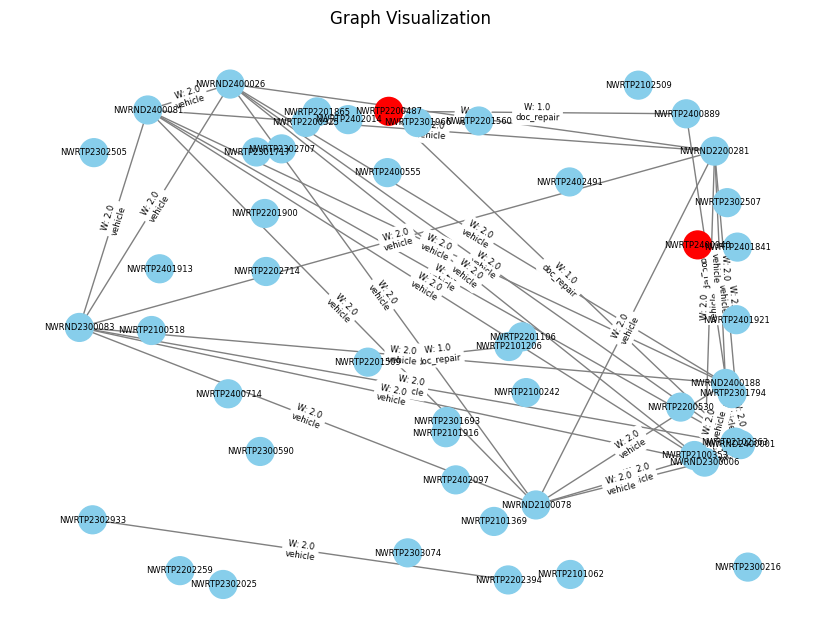

In [33]:
visualize_G(G_sub)

In [34]:
edge_index = data.edge_index
num_nodes = data.num_nodes

# Calculate the degree of each node
node_degrees = degree(edge_index[0], num_nodes=num_nodes)
node_degrees

tensor([ 1.,  1.,  2.,  ...,  0.,  0., 44.])

In [35]:
save_data(G, conf.data_path, 'ctp_network', data_extension='pkl')

Data saved successfully locally as pickle: C:\GitHub\CTP_syndicate_model\data\ctp_network.pkl


In [36]:
save_data(all_nodes_df, conf.data_path, 'node_data', data_extension='csv')

Data saved successfully locally as CSV: C:\GitHub\CTP_syndicate_model\data\node_data.csv


### 2.5 Investigated Graph Analysis

Nodes in the subgraph: [(5632, {'x': [2.0, 2.0, 1.0, 0.0, 0.0, 1.0, 175.0, 8.0, 0.0, 0.0, 0.0, 0.0, 85.0, 0.0, 0.0, 0.0, 0.0, 326.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 3.0, 0.0, 0.0, 1.0, 0.0], 'y': 1, 'claim_number': 'NWRTP2201860', 'policy_number': 'CTP711296287', 'claim_lodgement_date': datetime.date(2022, 9, 7), 'claim_loss_date': datetime.date(2022, 9, 5), 'investigation_flag': 1, 'triage_flag': 1, 'alleged_flag': 0}), (11781, {'x': [3.0, 3.0, 0.0, 0.0, 0.0, 1.0, 124.0, 8.0, 0.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 1.0, 0.0, 121.0, 0.0, 120.87999725341797, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 34.03232192993164], 'y': 1, 'claim_number': 'NWRTP2402050', 'policy_number': 'CTP784682014', 'claim_lodgement_date': datetime.date(2024, 8, 6), 'claim_loss_date': datetime.date(2024, 8, 3), 'investigation_flag': 1, 'triage_flag': 1, 'alleged_flag': 0}), (903, {'x': [12.0, 12.0, 0.0, 0.0, 1.0, 1.0, 115.0, 5.0, 0.0, 0.0, 0.0, 0.0, 148.0, 0.0, 0.0, 0.0, 0.0, 160.0, 1.0, 675.739990234375, 1.0, 1.0, 0.0, 

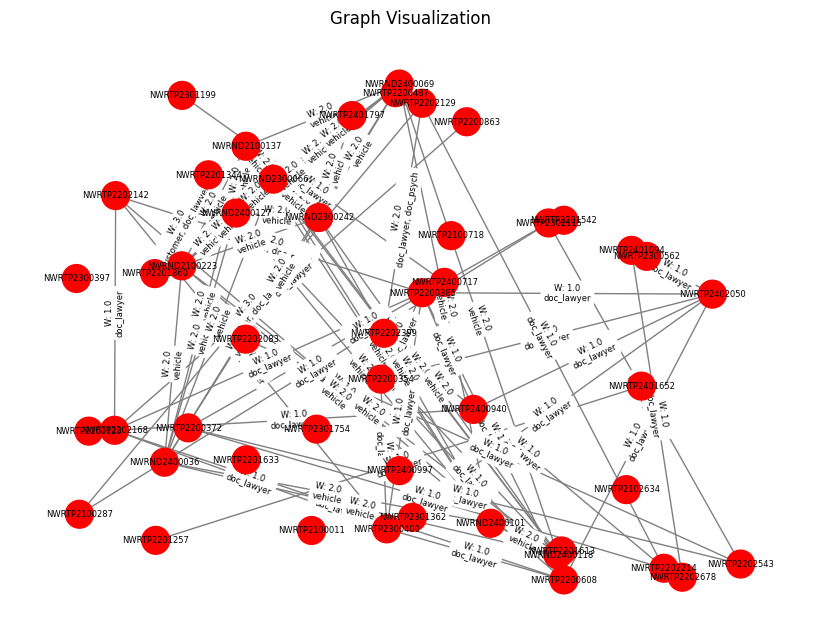

In [37]:
nodes_with_y_1 = [n for n, attr in G.nodes(data=True) if attr.get("y") == 1]
subG = G.subgraph(nodes_with_y_1)

# Output the nodes and edges of the subgraph
print(f"Nodes in the subgraph: {subG.nodes(data=True)}")
print(f"Edges in the subgraph: {subG.edges()}")

# Draw the subgraph

visualize_G(subG)


In [38]:
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities

# Find the communities using greedy modularity maximization
communities = greedy_modularity_communities(subG,weight='edge_weight')
# communities =louvain_communities(subG, resolution=0.5)

# Convert the result to a list of sets of nodes
communities = list(communities)
for i, community in enumerate(communities):
    print(f"Community {i+1}: {community}")

Community 1: frozenset({4384, 4162, 4131, 11781, 10830, 6447, 6959, 5938, 10679, 5912, 4638})
Community 2: frozenset({903, 11528, 137, 585, 813, 846, 878, 761, 222, 894})
Community 3: frozenset({5984, 1250, 6312, 5899, 8665, 4149, 6169, 5853})
Community 4: frozenset({5632, 5118})
Community 5: frozenset({10456, 7753})
Community 6: frozenset({11384, 5031})
Community 7: frozenset({3591})
Community 8: frozenset({1680})
Community 9: frozenset({5406})
Community 10: frozenset({4263})
Community 11: frozenset({6956})
Community 12: frozenset({3897})
Community 13: frozenset({5316})
Community 14: frozenset({976})
Community 15: frozenset({7121})
Community 16: frozenset({8165})
Community 17: frozenset({7916})
Community 18: frozenset({10734})
Community 19: frozenset({8306})


In [59]:
# # Function to visualize a community with claim numbers as node labels
# def visualize_community(G, communities, community_idx):
#     # Create a subgraph containing only the nodes in the cluster
#     selected_community = communities[community_idx]
#     community_subgraph = G.subgraph(selected_community)

#     # Create a color map for nodes based on an attribute 'y'
#     color_map = []
#     for node in community_subgraph.nodes(data=True):
#         if node[1].get('y') == 1:
#             color_map.append('red')
#         else:
#             color_map.append('skyblue')

#     # Create edge labels based on an attribute 'label'
#     edge_labels = nx.get_edge_attributes(community_subgraph, 'edge_weight')

#     # Plot the subgraph for the selected community
#     pos = nx.spring_layout(community_subgraph)  # You can change the layout as needed
#     plt.figure(figsize=(6, 4))
#     nx.draw(community_subgraph, pos, with_labels=False, node_color=color_map, edge_color='grey', node_size=800, font_size=10)
#     # nx.draw_networkx_edge_labels(community_subgraph, pos, edge_labels=edge_labels, font_size=6, label_pos=0.5)
#     nx.draw_networkx_labels(community_subgraph, pos, labels={node: data['claim_number'] for node, data in community_subgraph.nodes(data=True)}, font_size=8)
#     plt.title(f'Subgraph for Community {community_idx}')
#     plt.show()

In [39]:
def visualize_community(G, communities, community_idx):
    # Create a subgraph containing only the nodes in the cluster
    selected_community = communities[community_idx]
    community_subgraph = G.subgraph(selected_community)

    # Create a color map for nodes based on an attribute 'y'
    color_map = []
    for node in community_subgraph.nodes(data=True):
        if node[1].get('y') == 1:
            color_map.append('red')
        else:
            color_map.append('skyblue')

    # Build a reverse mapping: index -> relationship string.
    # (Assumes that rel_to_id is defined globally.)
    id_to_rel = {v: k for k, v in rel_to_id.items()}

    # Create edge labels that combine the edge weight and edge type
    edge_labels = {}
    for u, v, data in community_subgraph.edges(data=True):
        # Get the edge weight
        weight = data.get('edge_weight', None)
        
        # Get the edge type (multi-hot vector) and decode it
        multi_hot_vec = data.get('edge_type', None)
        if multi_hot_vec is not None:
            # If it's a tensor, convert it to a list; otherwise, assume it's already a list
            if hasattr(multi_hot_vec, 'tolist'):
                multi_hot_vec = multi_hot_vec.tolist()
            present_rels = [id_to_rel[i] for i, val in enumerate(multi_hot_vec) if val > 0]
            type_str = ", ".join(present_rels)
        else:
            type_str = ""
        
        # Combine weight and type info into one label string
        if weight is not None:
            label = f"W: {weight}\n{type_str}"
        else:
            label = type_str
        edge_labels[(u, v)] = label

    # Plot the subgraph for the selected community
    pos = nx.kamada_kawai_layout(community_subgraph)  # You can change the layout as needed
    plt.figure(figsize=(6, 4))
    nx.draw(community_subgraph, pos, with_labels=False, node_color=color_map, edge_color='grey', node_size=400, font_size=6)
    nx.draw_networkx_edge_labels(community_subgraph, pos, edge_labels=edge_labels, font_size=6, label_pos=0.5)
    nx.draw_networkx_labels(community_subgraph, pos, labels={node: data['claim_number'] for node, data in community_subgraph.nodes(data=True)}, font_size=6)
    plt.title(f'Subgraph for Community {community_idx}')
    plt.show()


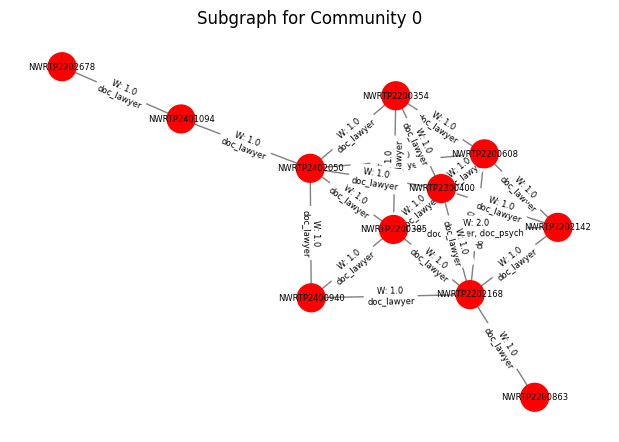

In [40]:
visualize_community(G, communities, 0)

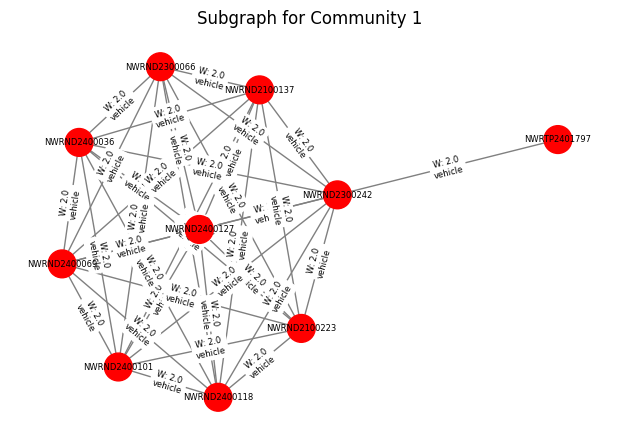

In [41]:
visualize_community(G, communities, 1)

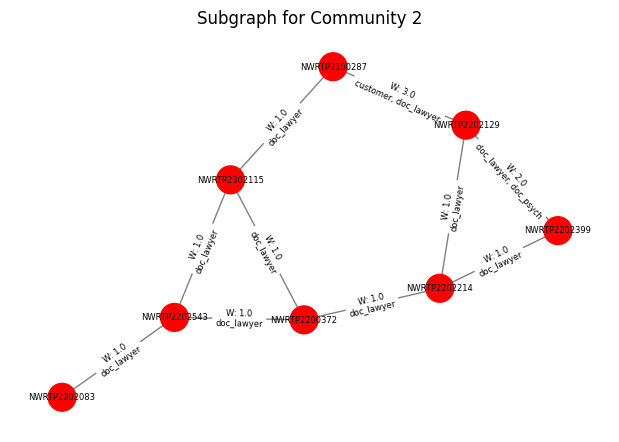

In [42]:
visualize_community(G, communities, 2)


### 2.6 Community Detection

In [43]:
def recursive_community_detection(G, communities_list,resolution,threshold,seed_value=42):

    random.seed(seed_value)
    np.random.seed(seed_value)
    # If the graph has 50 or fewer nodes, append it to the final communities list
    if G.number_of_nodes() <= threshold:
        communities_list.append(set(G.nodes))
    else:
        # Perform community detection on the subgraph
        # communities = nx.community.greedy_modularity_communities(G, weight='edge_weight', resolution=resolution)
        communities = louvain_communities(G, weight='edge_weight', resolution=resolution, seed=seed_value)
        
        # Apply the function recursively on the detected communities
        for community in communities:
            subgraph = G.subgraph(community)
            recursive_community_detection(subgraph, communities_list,resolution=resolution,threshold=threshold)

In [44]:
final_communities=[]
recursive_community_detection(G, final_communities, resolution=1.2, threshold=30)

len(final_communities)

1156

In [ ]:
# final_communities = louvain_communities(G, weight='edge_weight', resolution=1, seed=42)
# len(final_communities)

151

In [45]:
community_sizes = [len(c) for c in final_communities]
max(community_sizes)

30

In [46]:
filtered_communities = []

for community in final_communities:
    # Check if any node in the community has attribute 'y' = 1
    if any(G.nodes[node].get('y') == 1 for node in community):
        filtered_communities.append(community)

In [47]:
len(filtered_communities)

34

In [53]:
# filtered_communities = [community for community in final_communities if len(community) > 3]

# # Print or use the filtered communities
# filtered_communities

### 2.7 Community Analysis

In [48]:
# Function to compute conductance
def compute_conductance(graph, community):
    vol_community = sum(dict(graph.degree(community)).values())
    edge_boundary = len(list(nx.edge_boundary(graph, community)))
    vol_rest = sum(dict(graph.degree(graph.nodes - community)).values())

    if vol_community>0 and vol_rest>0:  
        return edge_boundary / min(vol_community, vol_rest)  
    else:
        return 0

In [49]:
def cal_metrics_community(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_number']for node, data in subgraph.nodes(data=True)]

        investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
        
        triage_list = [data['triage_flag'] for node, data in subgraph.nodes(data=True) if data['triage_flag'] != 0]
        
        allege_list = [data['alleged_flag'] for node, data in subgraph.nodes(data=True) if data['alleged_flag'] != 0]

        # Clustering coefficient (average for nodes in the community)
        avg_clustering = nx.average_clustering(subgraph)
        
        # Conductance
        conductance = compute_conductance(G, community)
        
        # Density
        density = nx.density(subgraph)
        
        # Triangle count (sum of triangles in the community)
        triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        # Calculate percentage of nodes with y == 1
        total_nodes = len(community)
        y_count = sum(1 for node, data in subgraph.nodes(data=True) if data.get('y', 0) == 1)
        y_percentage = (y_count / total_nodes * 100) if total_nodes > 0 else 0
        
        # Add metrics to the list
        community_metrics.append({
            'Community': i,
            'Nodes': node_list,
            'Claim Numbers': claim_list,
            'Investigated count': len(investigation_list),
            'Triaged count':len(triage_list),
            'Alleged count':len(allege_list),
            'Clustering Coefficient': avg_clustering,
            'Conductance': conductance,
            'Density': density,
            'Triangle Count': triangles,
            'Size': len(community),
            'investigation_rate': y_percentage # Optionally add community size
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [50]:
df_metrics = cal_metrics_community(G, final_communities)
df_metrics

,Community,Nodes,Claim Numbers,Investigated count,Triaged count,Alleged count,Clustering Coefficient,Conductance,Density,Triangle Count,Size,investigation_rate
0,0,[6],[NWRND2100005],0,0,0,0.000,1.000,0.000,0,1,0.000
1,1,[7],[NWRND2100007],0,0,0,0.000,1.000,0.000,0,1,0.000
2,2,[9],[NWRND2100009],0,0,0,0.000,1.000,0.000,0,1,0.000
3,3,[13],[NWRND2100013],0,0,0,0.000,1.000,0.000,0,1,0.000
4,4,[15],[NWRND2100015],0,0,0,0.000,1.000,0.000,0,1,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
1151,1151,"[12058, 12051, 12054]","[NWRTP2402329, NWRTP2402322, NWRTP2402325]",0,1,0,1.000,0.000,1.000,1,3,0.000
1152,1152,"[12057, 12125, 12126]","[NWRTP2402328, NWRTP2402396, NWRTP2402397]",0,0,0,1.000,0.000,1.000,1,3,0.000
1153,1153,"[12130, 295, 5319, 11823, 6034, 4024, 5563, 3964]","[NWRTP2402401, NWRND2200058, NWRTP2201545, NWR...",0,3,0,0.433,0.965,0.321,2,8,0.000
1154,1154,[12220],[NWRTP2402491],0,0,0,0.000,0.000,0.000,0,1,0.000


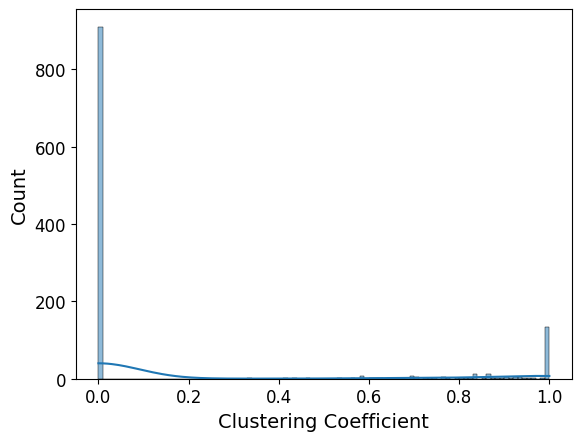

In [51]:
sns.histplot(df_metrics['Clustering Coefficient'], kde=True, bins=100) 
plt.show()

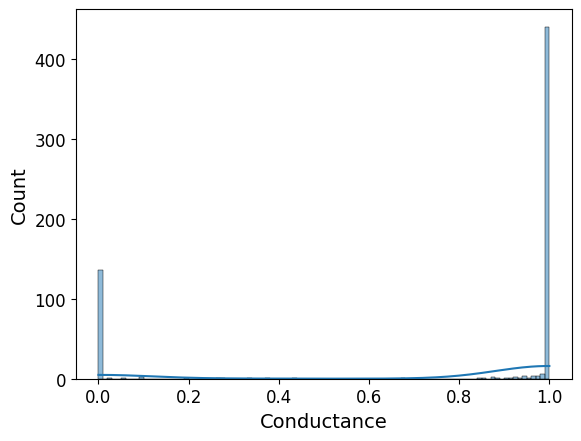

In [108]:
sns.histplot(df_metrics['Conductance'], kde=True, bins=100) 
plt.show()

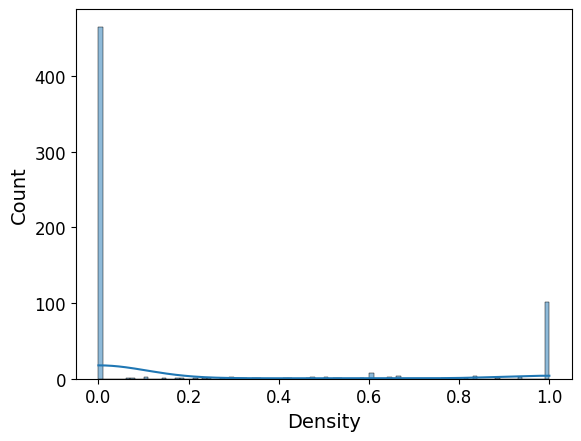

In [109]:
sns.histplot(df_metrics['Density'], kde=True, bins=100) 
plt.show()

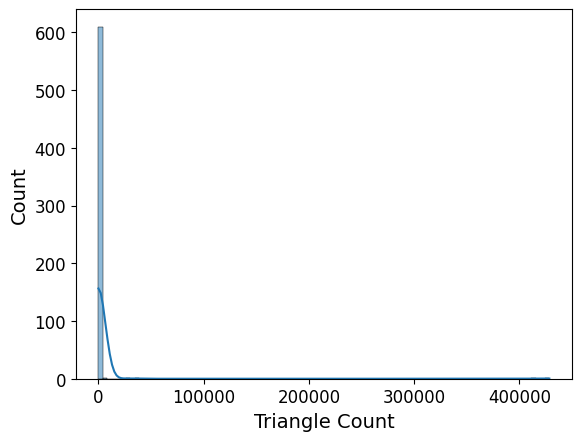

In [110]:
sns.histplot(df_metrics['Triangle Count'], kde=True, bins=100) 
plt.show()

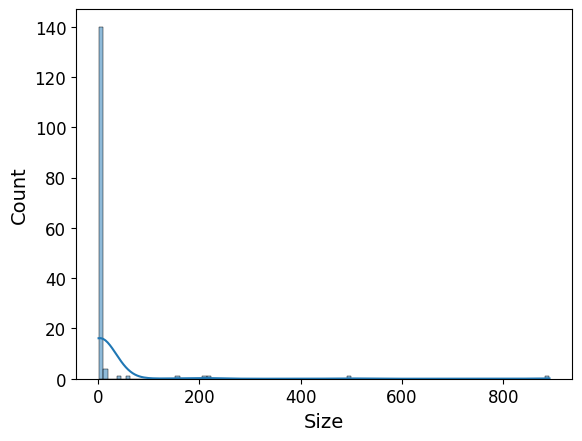

In [132]:
sns.histplot(df_metrics['Size'], kde=True, bins=100) 
plt.show()

In [52]:
# Filter communities based on criteria 
filtered_metrics = df_metrics[
    (df_metrics['Clustering Coefficient'] > 0.8) &  
    (df_metrics['Conductance'] < 0.5) &             
    (df_metrics['Density'] > 0.8) &                 
    # (df_metrics['Triangle Count'] > 2) &
    (df_metrics['Size'] >=4 ) &
    (df_metrics['Size'] <=50)         
].reset_index(drop=True)  

In [53]:
ranked_metrics = filtered_metrics.sort_values(by=['Size','Clustering Coefficient','Density','Conductance'], ascending=[False,False,False,True]).reset_index(drop=True)
filtered_communities = ranked_metrics['Nodes'].tolist()
len(filtered_communities)

35

In [54]:
ranked_metrics.head(10)

,Community,Nodes,Claim Numbers,Investigated count,Triaged count,Alleged count,Clustering Coefficient,Conductance,Density,Triangle Count,Size,investigation_rate
0,616,"[2529, 6370, 3589, 5671, 1959, 4041, 6028, 942...","[NWRTP2101570, NWRTP2202601, NWRTP2102632, NWR...",0,0,0,0.934,0.000,0.890,560,17,0.000
1,719,"[12032, 8544, 7391, 12009, 11947, 9231, 12146,...","[NWRTP2402303, NWRTP2301993, NWRTP2300836, NWR...",0,0,0,0.929,0.062,0.883,455,16,0.000
2,963,"[3009, 3178, 10668, 9168, 5716, 11286, 5463, 1...","[NWRTP2102051, NWRTP2102220, NWRTP2400929, NWR...",0,1,0,1.000,0.000,1.000,220,12,0.000
3,983,"[6821, 4102, 10151, 10154, 4109, 10990, 5457, ...","[NWRTP2300262, NWRTP2200325, NWRTP2400410, NWR...",0,8,0,1.000,0.000,1.000,220,12,0.000
4,1061,"[5250, 2758, 1928, 1930, 2732, 3797, 6229, 434...","[NWRTP2201476, NWRTP2101800, NWRTP2100967, NWR...",0,1,0,1.000,0.275,1.000,220,12,0.000
5,808,"[6658, 9986, 12066, 8455, 9867, 10061, 10449, ...","[NWRTP2300099, NWRTP2400245, NWRTP2402337, NWR...",0,3,0,1.000,0.337,1.000,220,12,0.000
6,625,"[2914, 5637, 4744, 3050, 3947, 1964, 5516, 917...","[NWRTP2101956, NWRTP2201865, NWRTP2200969, NWR...",0,0,0,1.000,0.100,1.000,120,10,0.000
7,730,"[7593, 7081, 8760, 8750, 5489, 2904]","[NWRTP2301039, NWRTP2300522, NWRTP2302212, NWR...",0,4,0,1.000,0.000,1.000,20,6,0.000
8,975,"[3756, 3757, 3758, 3759, 3760, 3761]","[NWRTP2102800, NWRTP2102801, NWRTP2102802, NWR...",0,0,0,1.000,0.000,1.000,20,6,0.000
9,986,"[10178, 4904, 4296, 9330, 11766, 3641]","[NWRTP2400437, NWRTP2201130, NWRTP2200520, NWR...",0,0,0,1.000,0.000,1.000,20,6,0.000


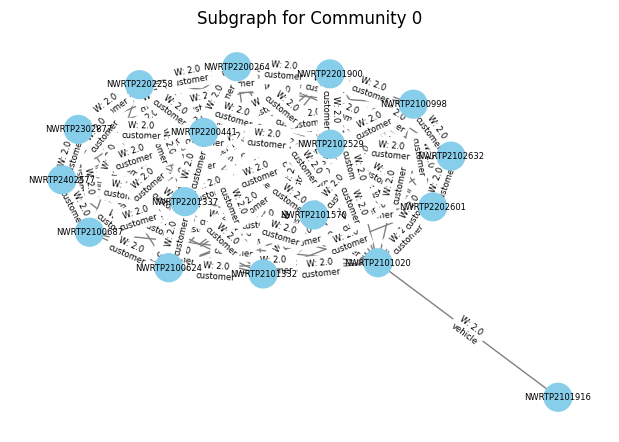

In [66]:
visualize_community(G, filtered_communities, 0)

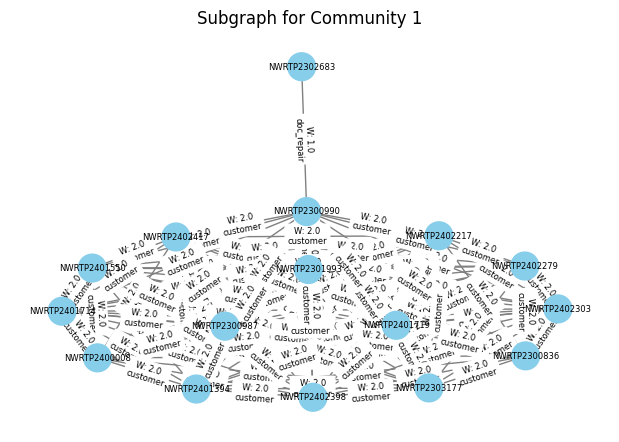

In [56]:
visualize_community(G, filtered_communities, 1)

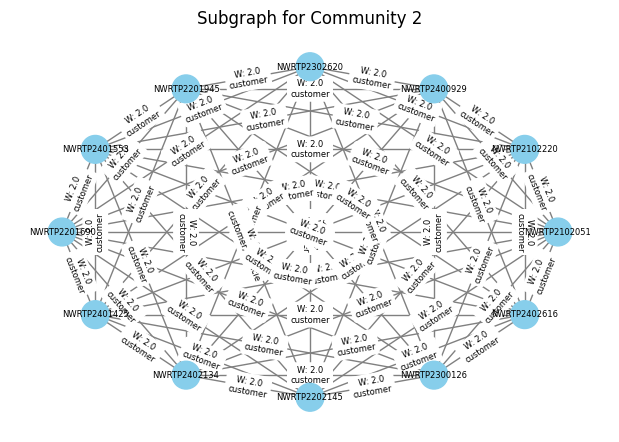

In [57]:
visualize_community(G, filtered_communities, 2)

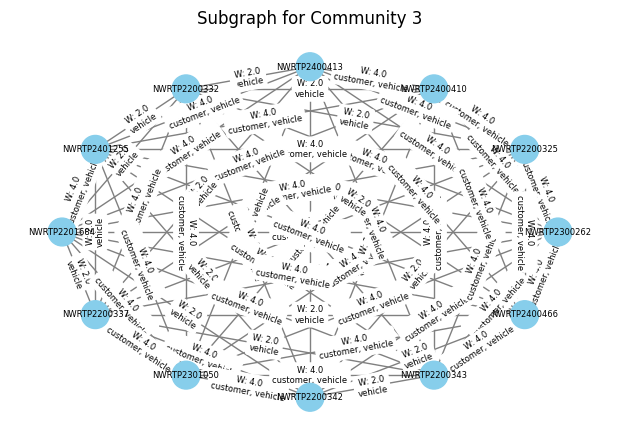

In [58]:
visualize_community(G, filtered_communities, 3)

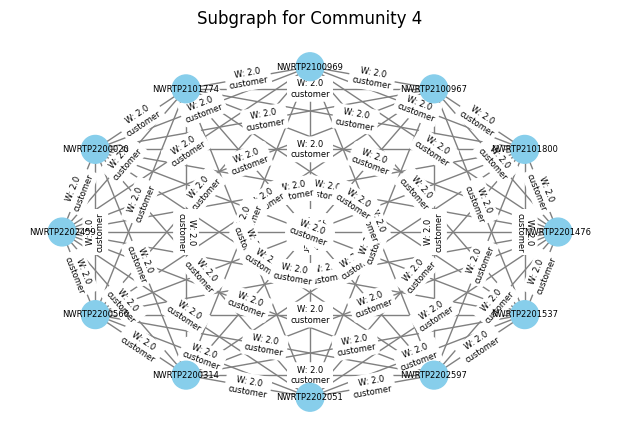

In [59]:
visualize_community(G, filtered_communities, 4)

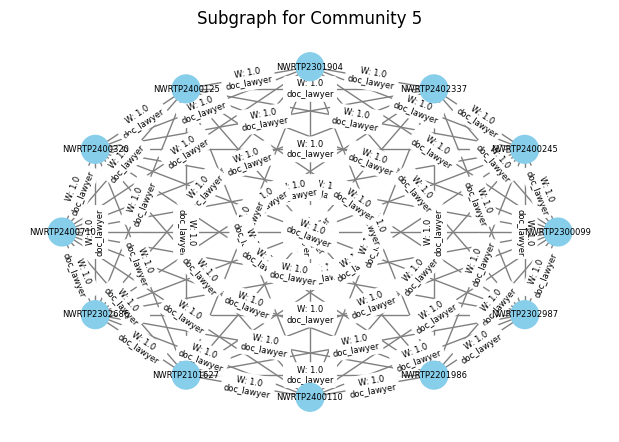

In [60]:
visualize_community(G, filtered_communities, 5)

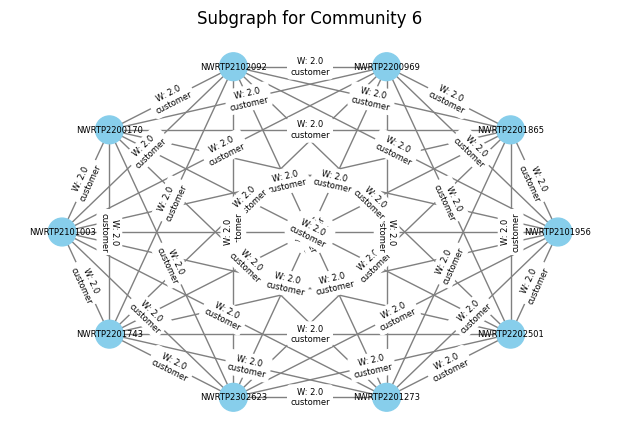

In [61]:
visualize_community(G, filtered_communities, 6)

# 3 Implement algorithms on Claim Network

In [63]:
import pytz
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, \
    f1_score, confusion_matrix, auc, precision_recall_curve,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
# from pygod.detector import DOMINANT
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from network import Dominant
import optuna

c:\Users\s745998\AppData\Local\miniconda3\envs\mygraphenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
# import torch
# import torch_geometric

# print("Torch version:", torch.__version__)
# print("Torch Geometric version:", torch_geometric.__version__)

Torch version: 2.4.1+cpu
Torch Geometric version: 2.5.3


### 3.1 Hyperparameter tuning on DOMINANT model

In [64]:
class networkEvaluator:
    """
    conf: from Conf class
    model_IF: isolation forest model
    x: input dataframe
    y: target value
    id_df: index columns of dataframe
    csv_filename: name of saving file
    thresh: threshold for model IF decision fucntion
    metric1: use as objective in HP, key in metrics dictionary
    metric2: use for comparison in plot, key in metrics dictionary
    """

    def __init__(self, conf):
        self.conf = conf

    @staticmethod
    def evaluate (conf, model, data, id_df, thresh, MODEL_TAG, csv_filename, metric1, metric2):
        anomaly_scores, y_emb=model.predict(data, get_emb=True)
        y_score = anomaly_scores.numpy()
        y_score = pd.Series(y_score, name='y_score')
        y_real= pd.Series(id_df['investigation_flag'], name='y')
        triage = pd.Series(id_df['triage_flag'], name='triage_flag')
        combined_df = pd.concat([y_score.reset_index(drop=True), 
                                 y_real.reset_index(drop=True), 
                                 triage.reset_index(drop=True)], axis=1)
        combined_df['y_pred'] = np.where(combined_df['y_score'] >= thresh, 1, 0)
        alert_vol =  sum(combined_df['y_pred'] == 1)
        inv_curr = sum(combined_df['y'])
        triage_curr = sum(combined_df['triage_flag'])

        t2i_curr = np.divide(inv_curr, triage_curr,
                                out=np.zeros_like(inv_curr, dtype=float), where=triage_curr != 0)

        inv_pred = sum(combined_df[combined_df['y_pred'] == 1]['y'])
        triage_pred = sum(combined_df[combined_df['y_pred'] == 1]['triage_flag'])

        t2i_pred = np.divide(inv_pred, triage_pred,
                                out=np.zeros_like(inv_pred, dtype=float), where=triage_pred != 0)
        
        precision = precision_score(combined_df['y'], combined_df['y_pred'])
        recall = recall_score(combined_df['y'], combined_df['y_pred'])
        f1 = f1_score(combined_df['y'], combined_df['y_pred'])
        conf_matrix = confusion_matrix(combined_df['y'], combined_df['y_pred'])
        precision2, recall2, _ = precision_recall_curve(combined_df['y'], combined_df['y_score'])
        pr_auc = auc(recall2, precision2)
        auc_roc_score = roc_auc_score(combined_df['y'], combined_df['y_score'])

        metrics = {
            "alert_vol": alert_vol,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Confusion Matrix": conf_matrix,
            "AUC-PR": pr_auc,
            "AUC-ROC": auc_roc_score,
            "Current T2I": t2i_curr,
            "New T2I": t2i_pred
        }
        # Print metrics
        print("Evaluation Metrics:")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value}")
        
        # Save meitrics to CSV
        networkEvaluator.save_metrics_to_csv(MODEL_TAG, metrics,
                                                     metric1, metric2, csv_filename)
        return metrics, combined_df

    @staticmethod
    def save_metrics_to_csv(MODEL_TAG, metrics, metric1, metric2, csv_filename):
        try:
            metric_df = pd.read_csv(csv_filename)
        except FileNotFoundError:
            metric_df = pd.DataFrame(columns=['Model', metric1, metric2])

        new_row = pd.DataFrame({'Model': [MODEL_TAG], 
                                metric1: [metrics[metric1]], 
                                metric2: [metrics[metric2]]})
        
        metric_df = pd.concat([metric_df, new_row], ignore_index=True)
        metric_df.to_csv(csv_filename, index=False)


# evaluator for Random forest 

In [65]:

class networkTrainer:
    """
    use metric1 as objective
    use metirc2 as comparison in plot

    """
    def __init__(self, conf, data, id_train, metric1, metric2):
        self.conf = conf
        self.data = data
        self.id_train = id_train
        self.metric1 = metric1
        self.metric2 = metric2
        self.metric_results = []

    def objective(self, trial):
        # Suggest values for the hyperparameters
        hidden_size = trial.suggest_int('hidden_size', 5, self.data.x.shape[1], step=1 )
        num_epochs = trial.suggest_int('num_epochs', 100, 200, step=5 )
        learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1) 
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
        dropout = trial.suggest_uniform('dropout', 0, 0.5) 
        # Create the model with suggested hyperparameters
        params={
            'hidden_size': hidden_size,
            'num_epochs': num_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'dropout': 0
        }
        # threshold = trial.suggest_uniform('threshold', 0, 0.5)  # Optimize threshold
        MODEL_TAG = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
        model = self.train_model(self.data, params)
        metrics, combined_df = networkEvaluator.evaluate(self.conf, model, self.data, self.id_train, 
                        500, MODEL_TAG, self.conf.artefact_path + "/metrics_train.csv", 
                        self.metric1, self.metric2)
        # Save the metrics for later plotting
        self.metric_results.append({self.metric1:metrics[self.metric1], self.metric2:metrics[self.metric2]})
        return metrics[self.metric1]
    

    def train_model(self, data, params):
        model = Dominant(feat_size=data.x.shape[1], hidden_size=params['hidden_size'], dropout=params['dropout'])
        model.train_model(data, num_epochs=params['num_epochs'], learning_rate=params['learning_rate'], weight_decay=params['weight_decay'])
        return model

    def train_with_optuna(self, n_trials=50):
        study = optuna.create_study(direction='maximize')
        study.optimize(self.objective, n_trials)  # 100 trials

        best_params = study.best_params

        # Plot A2I and "New R2I" curves after all trials are finished
        self.plot_metrics_curve()

        return best_params, study

    def plot_metrics_curve(self):
        # Retrieve the desired metrics from the results
        metric1_values = [result[self.metric1] for result in self.metric_results]
        metric2_values = [result[self.metric2] for result in self.metric_results]
        trials = np.arange(1, len(metric1_values) + 1)

        # Plot the selected metrics
        plt.figure(figsize=(10, 6))
        plt.plot(trials, metric1_values, marker='o', linestyle='-', color='b', label=self.metric1)
        plt.plot(trials, metric2_values, marker='o', linestyle='-', color='r', label=self.metric2)
        plt.title('Performance Metrics for Hyperparameter Tuning Trials')
        plt.xlabel('Trial')
        plt.ylabel('Score')
        plt.legend()
        plt.tight_layout()
        plt.show()

[I 2025-03-18 09:53:50,104] A new study created in memory with name: no-name-4474d069-50d9-40f4-9a3e-3ae18b30c4aa


************************************************************
HP tuning started...


C:\Users\s745998\AppData\Local\Temp\ipykernel_16684\1914236792.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_16684\1914236792.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_16684\1914236792.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0, 0.5)


Epoch 1/180, Loss: 27427876864.00, Struct loss: 27348938752.00, Attr loss: 78938.30
Epoch 2/180, Loss: 6202796032.00, Struct loss: 6130023936.00, Attr loss: 72772.01
Epoch 3/180, Loss: 1580643328.00, Struct loss: 1511045504.00, Attr loss: 69597.82
Epoch 4/180, Loss: 464378432.00, Struct loss: 396983776.00, Attr loss: 67394.66
Epoch 5/180, Loss: 178895136.00, Struct loss: 113340560.00, Attr loss: 65554.57
Epoch 6/180, Loss: 99351664.00, Struct loss: 35415880.00, Attr loss: 63935.79
Epoch 7/180, Loss: 73709840.00, Struct loss: 11241564.00, Attr loss: 62468.28
Epoch 8/180, Loss: 64677696.00, Struct loss: 3618408.50, Attr loss: 61059.29
Epoch 9/180, Loss: 60650020.00, Struct loss: 1121643.25, Attr loss: 59528.38
Epoch 10/180, Loss: 58466796.00, Struct loss: 520657.59, Attr loss: 57946.14
Epoch 11/180, Loss: 56693804.00, Struct loss: 343656.72, Attr loss: 56350.15
Epoch 12/180, Loss: 55004736.00, Struct loss: 241658.06, Attr loss: 54763.07
Epoch 13/180, Loss: 53399084.00, Struct loss: 16520

[I 2025-03-18 10:00:17,161] Trial 0 finished with value: 0.0 and parameters: {'hidden_size': 9, 'num_epochs': 180, 'learning_rate': 0.023701690014482423, 'weight_decay': 3.5043047088388306e-05, 'dropout': 0.4616037226041284}. Best is trial 0 with value: 0.0.


...

Evaluation Metrics:
alert_vol: 108
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix: [[12208   108]
 [   95     0]]
AUC-PR: 0.01712410615030681
AUC-ROC: 0.736185706227244
Current T2I: 0.0682961897915169
New T2I: 0.0


C:\Users\s745998\AppData\Local\Temp\ipykernel_16684\1914236792.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_16684\1914236792.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_16684\1914236792.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0, 0.5)


Epoch 1/135, Loss: 4490110464.00, Struct loss: 4414436352.00, Attr loss: 75674.20
Epoch 2/135, Loss: 103949072.00, Struct loss: 32764258.00, Attr loss: 71184.81
Epoch 3/135, Loss: 118557248.00, Struct loss: 53254464.00, Attr loss: 65302.79
Epoch 4/135, Loss: 82288384.00, Struct loss: 22612310.00, Attr loss: 59676.07
Epoch 5/135, Loss: 59996588.00, Struct loss: 5404096.50, Attr loss: 54592.49
Epoch 6/135, Loss: 50804428.00, Struct loss: 513792.94, Attr loss: 50290.64
Epoch 7/135, Loss: 47186804.00, Struct loss: 34.15, Attr loss: 47186.77
Epoch 8/135, Loss: 45095508.00, Struct loss: 0.41, Attr loss: 45095.51
Epoch 9/135, Loss: 42910260.00, Struct loss: 0.89, Attr loss: 42910.26
Epoch 10/135, Loss: 40302220.00, Struct loss: 0.17, Attr loss: 40302.22
Epoch 11/135, Loss: 37792260.00, Struct loss: 0.00, Attr loss: 37792.26
Epoch 12/135, Loss: 35644168.00, Struct loss: 0.04, Attr loss: 35644.17
Epoch 13/135, Loss: 33806492.00, Struct loss: 68.88, Attr loss: 33806.43
Epoch 14/135, Loss: 323600

[I 2025-03-18 12:48:18,323] Trial 49 finished with value: 0.0 and parameters: {'hidden_size': 6, 'num_epochs': 135, 'learning_rate': 0.07265411662574278, 'weight_decay': 2.930118227650436e-05, 'dropout': 0.2595147033039206}. Best is trial 1 with value: 0.12987012987012986.


Evaluation Metrics:
alert_vol: 112
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix: [[12204   112]
 [   95     0]]
AUC-PR: 0.016901825767386067
AUC-ROC: 0.7310165638194219
Current T2I: 0.0682961897915169
New T2I: 0.0


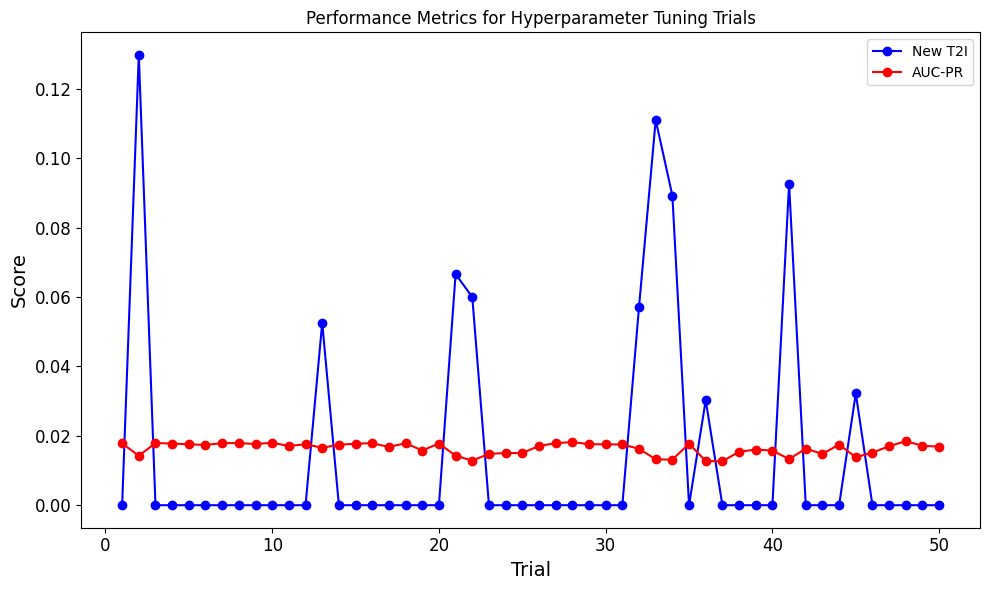

Best Parameters: {'hidden_size': 5, 'num_epochs': 100, 'learning_rate': 0.034123014049662705, 'weight_decay': 9.673410564957844e-05, 'dropout': 0.25899763041030655}
HP tuning finished...
************************************************************

Elapsed time (model HP tuning): 2:54:28.583
Total elapsed time: 22:14:16.975


In [67]:
# init params
hptrial = 50 # number of trials in HP tuning
metric1 = 'New T2I' # use as objective in HP tuning
metric2 = 'AUC-PR'  # use for HP tuning tracking

# train_tag = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
print('*' * 60)
print('HP tuning started...')
# use New T2D as objective
# run on 2024-02-16
function_start_time = time.time()
# Instantiate the trainer
trainer = networkTrainer(conf, data, all_nodes_df, metric1, metric2)
# Train with Optuna
best_params, study = trainer.train_with_optuna(n_trials=hptrial)
trial_data = study.trials_dataframe()
# save_pkl(best_params, conf.artefact_path, "best_params", data_extension="pkl")
# save_pkl(trial_data, conf.artefact_path, "trial_data_{}".format(train_tag), data_extension="pkl")
print("Best Parameters:", best_params)
print('HP tuning finished...')
print('*' * 60)
elapsed_time('model HP tuning', project_start_time, function_start_time)

### 3.2 Train model and extract network embeddings

In [96]:
# Initialize model
model = Dominant(feat_size=data.x.shape[1], hidden_size=5, dropout=0)
model.train_model(data, num_epochs=100, learning_rate=0.03412, weight_decay=9.673410564957844e-05)

Epoch 1/100, Loss: 962357376.00, Struct loss: 890531904.00, Attr loss: 71825.48
Epoch 2/100, Loss: 206293824.00, Struct loss: 136235296.00, Attr loss: 70058.54
Epoch 3/100, Loss: 101555344.00, Struct loss: 31707684.00, Attr loss: 69847.66
Epoch 4/100, Loss: 79378000.00, Struct loss: 9415671.00, Attr loss: 69962.33
Epoch 5/100, Loss: 73425616.00, Struct loss: 3279256.75, Attr loss: 70146.36
Epoch 6/100, Loss: 71615400.00, Struct loss: 1277157.50, Attr loss: 70338.24
Epoch 7/100, Loss: 71058472.00, Struct loss: 541540.88, Attr loss: 70516.93
Epoch 8/100, Loss: 70924792.00, Struct loss: 245755.97, Attr loss: 70679.04
Epoch 9/100, Loss: 70940632.00, Struct loss: 119155.27, Attr loss: 70821.48
Epoch 10/100, Loss: 71014264.00, Struct loss: 61031.59, Attr loss: 70953.23
Epoch 11/100, Loss: 71107944.00, Struct loss: 32680.49, Attr loss: 71075.27
Epoch 12/100, Loss: 71204584.00, Struct loss: 18180.24, Attr loss: 71186.40
Epoch 13/100, Loss: 71294960.00, Struct loss: 10542.92, Attr loss: 71284.4

Dominant(
  (shared_encoder): Encoder(
    (gc1): GCNConv(29, 5)
    (gc2): GCNConv(5, 5)
  )
  (attr_decoder): Attribute_Decoder(
    (gc1): GCNConv(5, 5)
    (gc2): GCNConv(5, 29)
  )
  (struct_decoder): Structure_Decoder(
    (gc1): GCNConv(5, 5)
  )
)

### 3.3 Evaluate graph anomaly detection model

In [97]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

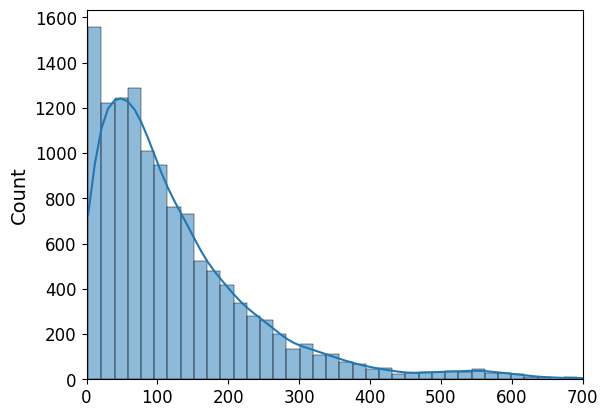

In [101]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(anomaly_scores, kde=True, bins=100) 
plt.xlim(0,700) 
plt.show()

In [103]:
train_tag=datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')

In [110]:
all_metrics_dfs = []
for thresh in range(200,320, 10):
        metrics, combined_df = networkEvaluator.evaluate(conf,model, data, all_nodes_df, 
                          thresh, train_tag, conf.artefact_path + "/metrics_train.csv", 
                          'New T2I', 'AUC-PR')
                # Convert metrics dict to DataFrame (assuming keys are the metric names)
        metrics_df = pd.DataFrame([metrics])
        
        # Add a column for the threshold to track which metrics belong to which threshold
        metrics_df['threshold'] = thresh
        # Append the DataFrame to the list
        all_metrics_dfs.append(metrics_df)
# Concatenate all the DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

Evaluation Metrics:
alert_vol: 2376
Precision: 0.01936026936026936
Recall: 0.4842105263157895
F1 Score: 0.03723188992310805
Confusion Matrix: [[9986 2330]
 [  49   46]]
AUC-PR: 0.01602383867832602
AUC-ROC: 0.7284354113604896
Current T2I: 0.0682961897915169
New T2I: 0.13813813813813813
Evaluation Metrics:
alert_vol: 2191
Precision: 0.020082154267457783
Recall: 0.4631578947368421
F1 Score: 0.03849518810148731
Confusion Matrix: [[10169  2147]
 [   51    44]]
AUC-PR: 0.01602383867832602
AUC-ROC: 0.7284354113604896
Current T2I: 0.0682961897915169
New T2I: 0.13924050632911392
Evaluation Metrics:
alert_vol: 2003
Precision: 0.021467798302546182
Recall: 0.45263157894736844
F1 Score: 0.04099142040038132
Confusion Matrix: [[10356  1960]
 [   52    43]]
AUC-PR: 0.01602383867832602
AUC-ROC: 0.7284354113604896
Current T2I: 0.0682961897915169
New T2I: 0.14675767918088736
Evaluation Metrics:
alert_vol: 1845
Precision: 0.022764227642276424
Recall: 0.4421052631578947
F1 Score: 0.04329896907216495
Confus

In [111]:
combined_metrics_df

,alert_vol,Precision,Recall,F1 Score,Confusion Matrix,AUC-PR,AUC-ROC,Current T2I,New T2I,threshold
0,2376,0.019,0.484,0.037,"[[9986, 2330], [49, 46]]",0.016,0.728,0.0682961897915169,0.13813813813813813,200
1,2191,0.020,0.463,0.038,"[[10169, 2147], [51, 44]]",0.016,0.728,0.0682961897915169,0.13924050632911392,210
2,2003,0.021,0.453,0.041,"[[10356, 1960], [52, 43]]",0.016,0.728,0.0682961897915169,0.14675767918088736,220
3,1845,0.023,0.442,0.043,"[[10513, 1803], [53, 42]]",0.016,0.728,0.0682961897915169,0.15384615384615385,230
4,1685,0.022,0.389,0.042,"[[10668, 1648], [58, 37]]",0.016,0.728,0.0682961897915169,0.14919354838709678,240
5,1549,0.022,0.358,0.041,"[[10801, 1515], [61, 34]]",0.016,0.728,0.0682961897915169,0.1504424778761062,250
6,1408,0.021,0.305,0.039,"[[10937, 1379], [66, 29]]",0.016,0.728,0.0682961897915169,0.145,260
7,1283,0.019,0.263,0.036,"[[11058, 1258], [70, 25]]",0.016,0.728,0.0682961897915169,0.14124293785310735,270
8,1186,0.019,0.242,0.036,"[[11153, 1163], [72, 23]]",0.016,0.728,0.0682961897915169,0.1411042944785276,280
9,1102,0.017,0.200,0.032,"[[11233, 1083], [76, 19]]",0.016,0.728,0.0682961897915169,0.13013698630136986,290


In [275]:
y_emb

tensor([[  0.0000,   0.0000,  69.9175,  ...,   0.0000, 304.6548,  71.8069],
        [  0.0000,   0.0000,  66.7464,  ...,   0.0000, 250.1793,  21.1363],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000, 428.3801,  36.4353],
        ...,
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,  67.4901,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,  19.3455,   0.0000],
        [  0.0000,   0.0000,  12.5766,  ...,   0.0000, 221.8319,  25.3223]])

ROC-AUC: 0.73


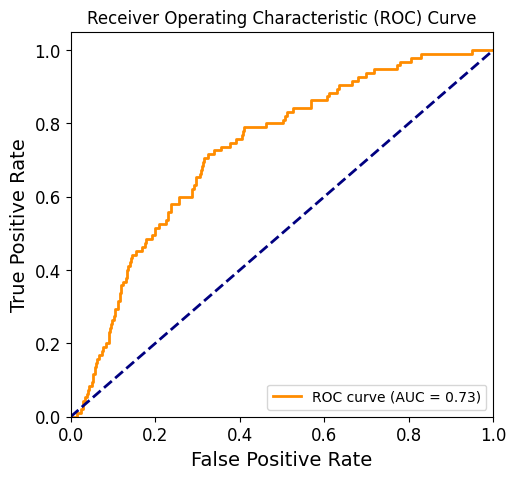

In [112]:
# ROC Curve
y_score=anomaly_scores
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# # PR curve
# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall (PR) Curve')
# plt.legend(loc="lower left")

# plt.tight_layout()
# plt.show()

# 4 Score Clusters

### 4.1 Anomaly Score

In [113]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

In [114]:
community_scores = []
for idx, community in enumerate(filtered_communities):
    community_anomaly_scores = [anomaly_scores[node] for node in community]
    if not community_anomaly_scores:
        continue
    
    # Calculate metrics for anomaly scores within the community
    mean_score = np.mean(community_anomaly_scores)
    max_score = np.max(community_anomaly_scores)
    sum_score = np.sum(community_anomaly_scores)
    normalized_score = sum_score / len(community)
            # Calculate the average degree for the community
    subgraph = G.subgraph(community)
    community_avg_degree = sum(dict(subgraph.degree()).values()) / len(subgraph.nodes()) if len(subgraph.nodes()) > 0 else 0
    claim_list=[data['claim_number']for node, data in subgraph.nodes(data=True)]
    investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
    
    triage_list = [data['triage_flag'] for node, data in subgraph.nodes(data=True) if data['triage_flag'] != 0]
    
    allege_list = [data['alleged_flag'] for node, data in subgraph.nodes(data=True) if data['alleged_flag'] != 0]
    # Append the computed metrics for each community
    community_scores.append({
        'community_index': idx,
        'community_claims': claim_list,
        'mean_score': mean_score,
        'max_score': max_score,
        'sum_score': sum_score,
        # 'normalized_score': normalized_score,
        'Investigated count': len(investigation_list),
        'Triaged count':len(triage_list),
        'Alleged count':len(allege_list),
        'community_size': len(community),
        'avg_connection':community_avg_degree
    })

In [115]:
community_scores_df = pd.DataFrame(community_scores)
community_scores_df.set_index('community_index', inplace=True)
community_scores_df

,community_claims,mean_score,max_score,sum_score,Investigated count,Triaged count,Alleged count,community_size,avg_connection
community_index,,,,,,,,,
0,"[NWRTP2202214, NWRTP2100287, NWRTP2202543, NWR...",217.402,310.560,2608.820,8,9,1,12,3.000
1,"[NWRTP2200385, NWRTP2200178, NWRND2200166, NWR...",324.909,430.392,1949.451,2,4,0,6,5.000
2,"[NWRTP2201189, NWRTP2101919, NWRTP2102634]",230.530,254.497,691.591,1,1,0,3,2.000
3,"[NWRTP2102765, NWRTP2102777, NWRTP2201633, NWR...",208.335,292.249,833.340,1,2,0,4,3.000
4,"[NWRTP2200961, NWRTP2200608, NWRTP2201167, NWR...",228.730,313.941,1829.842,2,2,0,8,5.750
...,...,...,...,...,...,...,...,...,...
171,"[NWRTP2200973, NWRTP2102768, NWRTP2300688]",112.416,154.555,337.249,0,0,0,3,2.000
172,"[NWRTP2102800, NWRTP2102801, NWRTP2102802, NWR...",5.815,5.815,34.889,0,0,0,6,5.000
173,"[NWRTP2302921, NWRTP2402196, NWRTP2200006]",133.178,239.410,399.534,0,0,0,3,2.000


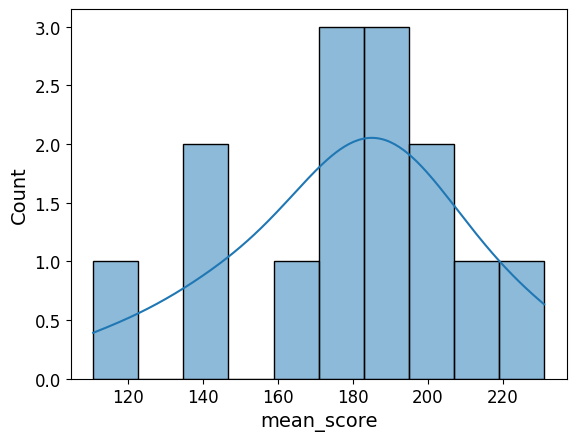

In [93]:
sns.histplot(community_scores_df['mean_score'], kde=True, bins=10) 
# plt.xlim(0,400) 
plt.show()

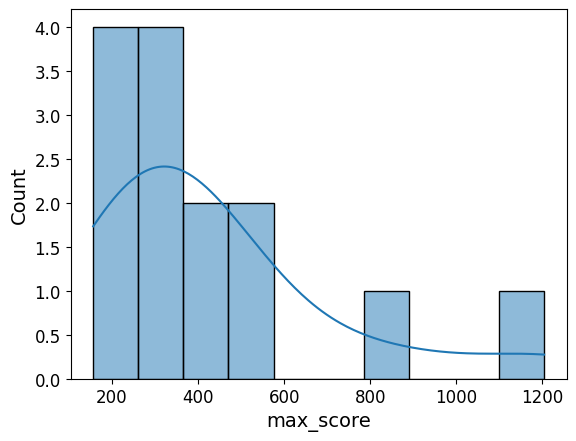

In [94]:
sns.histplot(community_scores_df['max_score'], kde=True, bins=10) 
# plt.xlim(0,500) 
plt.show()

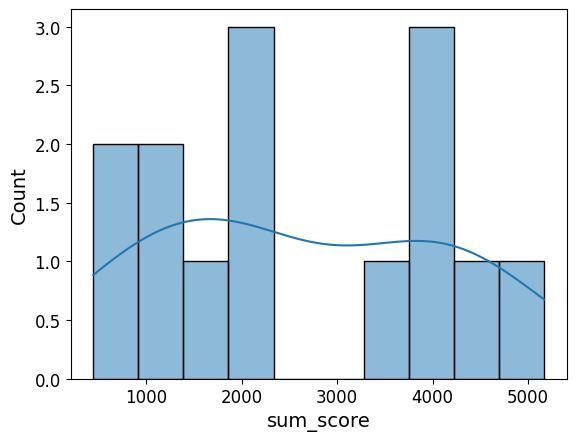

In [95]:
sns.histplot(community_scores_df['sum_score'], kde=True, bins=10) 
plt.show()

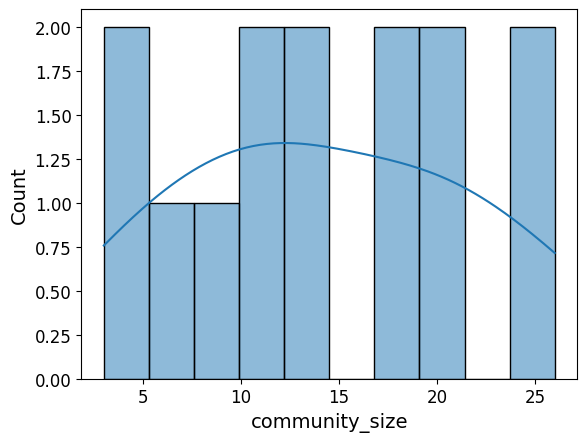

In [96]:
sns.histplot(community_scores_df['community_size'], kde=True, bins=10) 
plt.show()

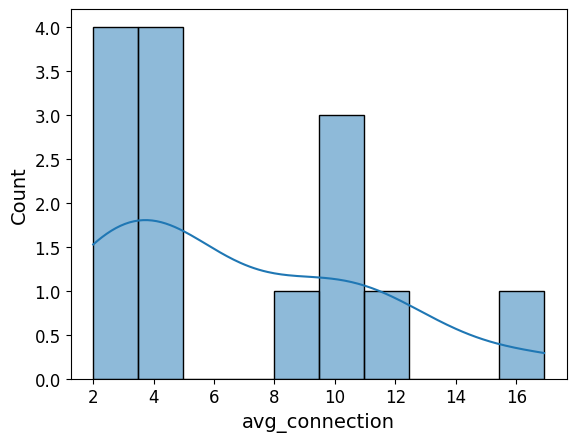

In [156]:
sns.histplot(community_scores_df['avg_connection'], kde=True, bins=10) 
plt.show()

In [97]:
community_scores_df['rank_mean'] = community_scores_df['mean_score'].rank(ascending=False, method='min')
community_scores_df['rank_max'] = community_scores_df['max_score'].rank(ascending=False, method='min')
community_scores_df['rank_sum'] = community_scores_df['sum_score'].rank(ascending=False, method='min')

# Calculate final rank using majority voting
# Majority voting can be simulated by summing ranks and then ranking communities again
community_scores_df['final_rank'] = (
    community_scores_df[['rank_mean', 'rank_max', 'rank_sum']].mean(axis=1)
).rank(ascending=True, method='min')

community_scores_df = community_scores_df.drop(columns=['rank_mean', 'rank_max', 'rank_sum']).sort_values(by='final_rank')
community_scores_df

,community_claims,mean_score,max_score,sum_score,Investigated count,Triaged count,Alleged count,community_size,avg_connection,final_rank
community_index,,,,,,,,,,
5,"[NWRTP2301129, NWRTP2201671, NWRTP2202540, NWR...",231.052,1203.809,4158.928,1,5,1,18,10.667,1.000
4,"[NWRTP2302025, NWRTP2201356, NWRTP2202774, NWR...",196.865,842.055,3937.292,1,4,0,20,4.100,2.000
8,"[NWRTP2400887, NWRTP2400116, NWRTP2301261, NWR...",198.813,371.082,5169.149,1,14,0,26,16.923,2.000
13,"[NWRTP2302800, NWRTP2402051, NWRTP2101997, NWR...",185.201,572.843,3889.228,1,12,0,21,8.381,4.000
3,"[NWRTP2300099, NWRTP2400245, NWRTP2301770, NWR...",171.727,527.976,4464.891,1,7,0,26,10.769,5.000
7,"[NWRTP2300487, NWRTP2201103, NWRTP2100591, NWR...",185.298,335.521,3520.669,1,10,0,19,11.684,6.000
9,"[NWRTP2202214, NWRTP2100287, NWRTP2202543, NWR...",193.800,333.071,2325.601,8,9,1,12,3.000,7.000
6,"[NWRTP2400307, NWRTP2201860, NWRTP2303055, NWR...",160.609,438.470,2087.917,2,5,0,13,3.692,8.000
1,"[NWRTP2101569, NWRTP2201158, NWRTP2301613, NWR...",181.466,364.883,1270.260,1,2,0,7,4.571,9.000


In [98]:
save_data(community_scores_df, conf.data_path, 'results', data_extension='csv')

Data saved successfully locally as CSV: C:\GitHub\CTP_syndicate_model\data\results.csv


In [99]:
# Step 1: Calculate Ranks Based on Scores

# Rank based on 'mean_score'
community_scores_df['mean_rank'] = community_scores_df['mean_score'].rank(method='min', ascending=False)

# Rank based on 'max_score'
community_scores_df['max_rank'] = community_scores_df['max_score'].rank(method='min', ascending=False)

# Rank based on 'sum_score'
community_scores_df['sum_rank'] = community_scores_df['sum_score'].rank(method='min', ascending=False)

# Step 2: Aggregate Ranks Using Sum of Ranks

# Calculate total rank by summing ranks across metrics
community_scores_df['total_rank'] = (
    community_scores_df['mean_rank'] +
    community_scores_df['max_rank'] +
    community_scores_df['sum_rank']
)

# Step 3: Select Top 30 Syndicates

# Sort communities based on 'total_rank' in ascending order
community_scores_df.sort_values('total_rank', ascending=True, inplace=True)

# Extract top 30 communities
top_30_communities_df = community_scores_df.head(30)

# Get the indices of the top 30 communities
top_30_indices = top_30_communities_df.index.tolist()

# Extract the actual communities
top_30_communities = [filtered_communities[idx] for idx in top_30_indices]

# Step 4: Analyze Top 30 Communities

for idx, community in zip(top_30_indices, top_30_communities):
    row = top_30_communities_df.loc[idx]
    print(f"Community Index: {idx}")
    print(f"Nodes: {community}")
    print(f"Mean Score: {row['mean_score']}")
    print(f"Max Score: {row['max_score']}")
    print(f"Sum Score: {row['sum_score']}")
    print(f"Total Rank: {row['total_rank']}")
    print(f"Community Size: {row['community_size']}")
    print("---")

Community Index: 5
Nodes: [7683, 5444, 6309, 4263, 9800, 5865, 3466, 4842, 5836, 3628, 11374, 6127, 11121, 8819, 1428, 2261, 1687, 6713]
Mean Score: 231.05154418945312
Max Score: 1203.8094482421875
Sum Score: 4158.927734375
Total Rank: 5.0
Community Size: 18
---
Community Index: 4
Nodes: [8576, 5130, 6542, 1680, 9618, 4499, 3476, 1437, 6051, 7466, 8875, 9265, 5179, 9149, 10066, 2399, 9314, 3821, 6767, 2547]
Mean Score: 196.8646240234375
Max Score: 842.054931640625
Sum Score: 3937.29248046875
Total Rank: 10.0
Community Size: 20
---
Community Index: 8
Nodes: [10626, 9858, 7815, 1543, 4745, 1554, 5398, 11287, 2464, 10533, 810, 12334, 193, 7492, 2629, 3531, 7375, 980, 1117, 10602, 6250, 7020, 10734, 2419, 6261, 7804]
Mean Score: 198.81341552734375
Max Score: 371.0820007324219
Sum Score: 5169.14892578125
Total Rank: 10.0
Community Size: 26
---
Community Index: 13
Nodes: [9348, 11782, 2955, 10508, 11406, 10776, 11564, 12205, 308, 7609, 11963, 6460, 7740, 3524, 10830, 10845, 8825, 10874, 1125

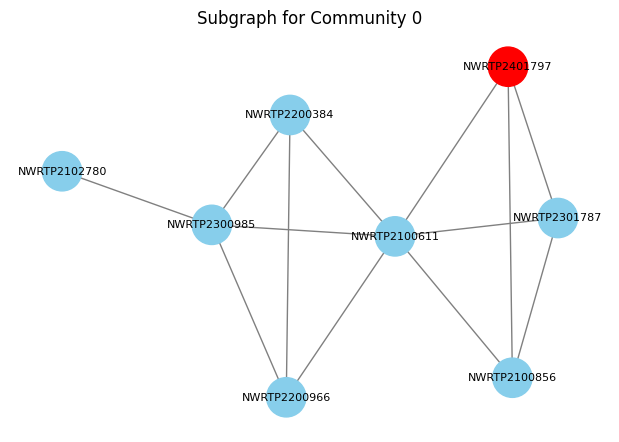

In [100]:
visualize_community(G, filtered_communities, 0)

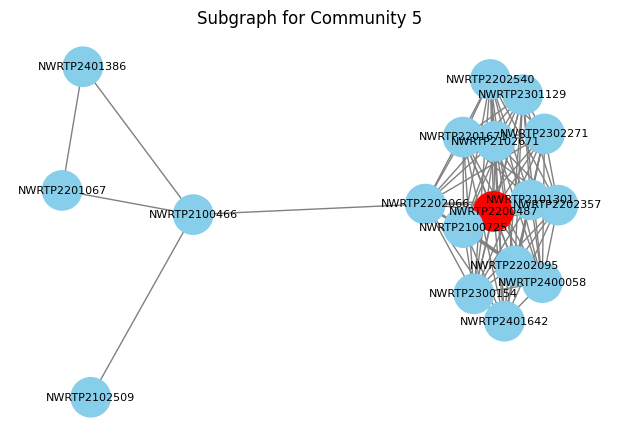

In [101]:
visualize_community(G, filtered_communities, 5)

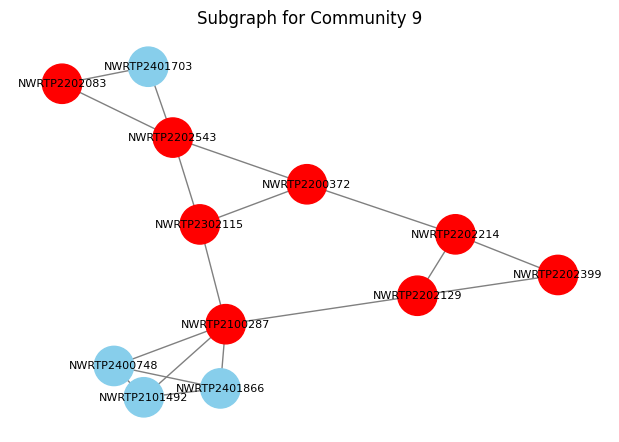

In [102]:
visualize_community(G, filtered_communities, 9)

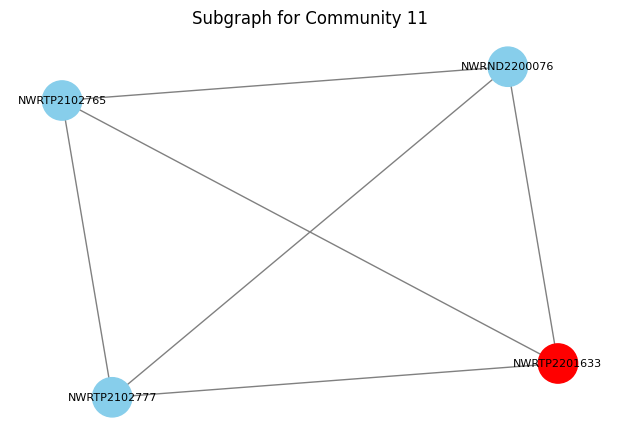

In [103]:
visualize_community(G, filtered_communities, 11)

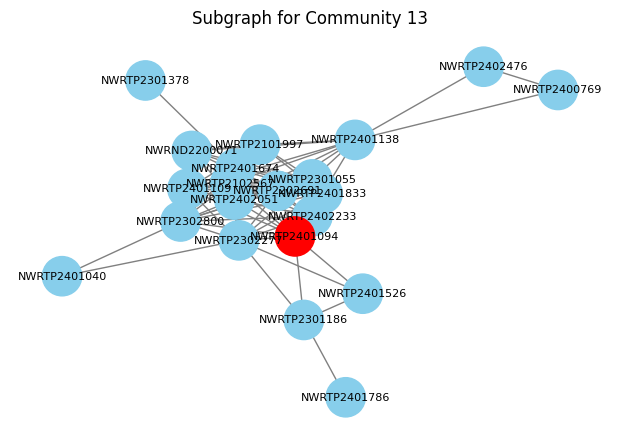

In [104]:
visualize_community(G, filtered_communities, 13)

In [60]:
# def average_anomaly_scores(final_communities, anomaly_scores, G):
#     """
#     Calculate the average anomaly scores for each community, rank the communities based on the average scores,
#     and select the top 30 communities with the largest anomaly scores and an average degree larger than the 
#     average degree of the global graph G.

#     Parameters:
#     final_communities (list of lists): A list of communities, each community is represented as a list of node indices.
#     anomaly_scores (numpy array or torch tensor): An array or tensor of anomaly scores for all nodes.
#     G (networkx.Graph): The global graph.

#     Returns:
#     list of tuples: A list of tuples where each tuple contains the community index and the average anomaly score, 
#                     for the top 30 communities that meet the average degree condition.
#     """
#     community_avg_scores = {}
    
#     # Calculate the average degree of the global graph
#     global_avg_degree = sum(dict(G.degree()).values()) / len(G.nodes())
    
#     for i, community in enumerate(final_communities):
#         # Extract anomaly scores for nodes in the community
#         community_scores = [anomaly_scores[node] for node in community]
#         # Calculate the average anomaly score for the community
#         avg_score = np.mean(community_scores)
        
#         # Calculate the average degree for the community
#         subgraph = G.subgraph(community)
#         community_avg_degree = sum(dict(subgraph.degree()).values()) / len(subgraph.nodes()) if len(subgraph.nodes()) > 0 else 0
#         # Store the result if the community average degree is greater than the global average degree
#         if community_avg_degree > global_avg_degree:
#             community_avg_scores[i] = avg_score
    
#     # Sort communities by average anomaly score in descending order
#     ranked_communities = sorted(community_avg_scores.items(), key=lambda x: x[1], reverse=True)
    
#     # Select the top 30 communities
#     top_30_communities = ranked_communities[:30]
    
#     return top_30_communities

In [96]:
global_avg_degree = sum(dict(G.degree()).values()) / len(G.nodes())
global_avg_degree


26.776280041797282